# ## 셀 1-1. 환경 설정

In [ ]:
# 구글 drive 마운트하기
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name()  # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

# 음수 표현하는 코드 추가
plt.rcParams['axes.unicode_minus'] = False

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [23]:
import ast
import gc
import os
import re
import shutil
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import seaborn as sns
from IPython.display import Markdown, display


wd = "/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data"
os.chdir(wd)
DATA_DIR = Path.cwd()

OUT_DIR = Path("/content/votes_hackle_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = selected_font
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 Colab에 NanumGothic을 설치한 뒤 다시 실행하세요.")
plt.rcParams["axes.unicode_minus"] = False

CHUNKSIZE = 1_000_000
TOP_N = 20

FILES = {
    "accounts_user": DATA_DIR / "accounts_user_master.csv",
    "attendance": DATA_DIR / "accounts_attendance_master.csv",
    "attendance_long": DATA_DIR / "accounts_attendance_long.csv",
    "payment": DATA_DIR / "accounts_paymenthistory_raw.csv",
    "question_record": DATA_DIR / "accounts_userquestionrecord_raw.csv",
    "friend_request": DATA_DIR / "accounts_friendrequest_raw.csv",
    "hackle_events": DATA_DIR / "hackle_events_raw.csv",
}

for name, path in FILES.items():
    print(f"{name:16s}", "OK" if path.exists() else "MISSING", path)

accounts_user    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_user_master.csv
attendance       OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_attendance_master.csv
attendance_long  OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_attendance_long.csv
payment          OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_paymenthistory_raw.csv
question_record  OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_userquestionrecord_raw.csv
friend_request   OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_friendrequest_raw.csv
hackle_events    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/hackle_events_raw.csv


In [24]:
ls

accounts_attendance_long.csv         accounts_userquestionrecord_raw.csv
accounts_attendance_master.csv       accounts_userwithdraw_raw.csv
accounts_blockrecord_raw.csv         device_properties_raw.csv
accounts_failpaymenthistory_raw.csv  event_receipts_raw.csv
accounts_friendrequest_raw.csv       events_raw.csv
accounts_group_raw.csv               hackle_events_raw.csv
accounts_nearbyschool_raw.csv        hackle_properties_raw.csv
accounts_paymenthistory_raw.csv      main_repo/
accounts_pointhistory_raw.csv        polls_questionpiece_raw.csv
accounts_school_raw.csv              polls_question_raw.csv
accounts_timelinereport_raw.csv      polls_questionreport_raw.csv
accounts_user_contacts_long.csv      polls_questionset_long.csv
accounts_user_contacts_master.csv    polls_questionset_master.csv
accounts_user_long.csv               polls_usercandidate_raw.csv
accounts_user_master.csv             user_properties_raw.csv


In [25]:
from google.colab import userdata
from pathlib import Path
import os

token = userdata.get("GITHUB_TOKEN")

Path("/root/.netrc").write_text(
    f"machine github.com\nlogin x-access-token\npassword {token}\n"
)
os.chmod("/root/.netrc", 0o600)
os.chdir("/content")

In [26]:
!pwd
!rm -rf main_repo
!git clone https://github.com/codeit-DA12-final3/main_repo.git
%cd /content/main_repo
!git switch -c feature/suhyun-analysis


/content
Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 30.32 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/main_repo
Switched to a new branch 'feature/suhyun-analysis'


In [27]:
!git clone https://github.com/codeit-DA12-final3/main_repo.git

Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 28.34 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [28]:
%cd main_repo

/content/main_repo/main_repo


In [29]:
!git switch -c feature/suhyun-analysis

Switched to a new branch 'feature/suhyun-analysis'


In [30]:
for p in TABLE_DIR.glob("*.csv"):
    p.unlink()

_TABLE_NO = 0

In [31]:
for p in FIG_DIR.glob("*.png"):
    p.unlink()

_FIG_NO = 0

# ## 셀 1-2. 공통 함수

In [32]:
def as_user_id(series):
    """숫자형 user id를 merge 가능한 문자열 id로 통일합니다."""
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def parse_date_list(value):
    """attendance_date_list 문자열을 날짜 리스트로 변환합니다."""
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
    except Exception:
        return []
    if not isinstance(parsed, list):
        return []
    return [pd.to_datetime(x, errors="coerce").date() for x in parsed if pd.notna(x)]


def longest_consecutive_streak(dates):
    """날짜 리스트에서 최장 연속 활동일 수를 계산합니다."""
    dates = sorted(pd.to_datetime(pd.Series(dates), errors="coerce").dropna().dt.date.unique())
    if not dates:
        return 0
    best = current = 1
    for prev, cur in zip(dates, dates[1:]):
        if (pd.Timestamp(cur) - pd.Timestamp(prev)).days == 1:
            current += 1
        else:
            best = max(best, current)
            current = 1
    return max(best, current)


def attendance_metrics_from_value(value):
    """attendance_date_list를 한 번만 파싱해서 날짜 리스트/활동일/최장 연속일을 같이 계산합니다."""
    dates = parse_date_list(value)
    unique_dates = sorted(set(dates))
    if not unique_dates:
        return [], 0, 0

    best = current = 1
    for prev, cur in zip(unique_dates, unique_dates[1:]):
        if (pd.Timestamp(cur) - pd.Timestamp(prev)).days == 1:
            current += 1
        else:
            best = max(best, current)
            current = 1
    return unique_dates, len(unique_dates), max(best, current)


def note(title, condition, meaning):
    NOTES_FOR_README.append(
        {
            "title": title,
            "condition": condition,
            "meaning": meaning,
        }
    )
    display(Markdown(f"### {title}\n- **조건**: {condition}\n- **의미**: {meaning}"))


_FIG_NO = 0
_TABLE_NO = 0
NOTES_FOR_README = []


def make_slug(value, fallback):
    value = str(value or fallback)
    value = re.sub(r"[^\w가-힣]+", "_", value, flags=re.UNICODE).strip("_")
    return value[:80] or fallback


def count_fmt(value, decimals=0):
    if pd.isna(value):
        return ""
    if abs(float(value)) >= 1000:
        return f"{value:,.{decimals}f}"
    return f"{value:.{decimals}f}"


def add_bar_labels(ax, decimals=0, fontsize=8, padding=3):
    """막대 위에 값을 직접 표시해 GitHub PNG에서도 수치가 보이게 합니다."""
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append("" if pd.isna(height) else count_fmt(height, decimals))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def format_count_axis(ax, axis="y"):
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
    if axis in ["y", "both"]:
        ax.yaxis.set_major_formatter(formatter)
    if axis in ["x", "both"]:
        ax.xaxis.set_major_formatter(formatter)


def rotate_xticks(ax, degrees=25):
    for label in ax.get_xticklabels():
        label.set_rotation(degrees)
        label.set_ha("right")


def pad_y_axis(ax, factor=1.18):
    ymin, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(ymin, ymax * factor)


def save_mpl_fig(title, filename=None, fig=None):
    """matplotlib/seaborn 그래프를 Colab에 표시하면서 GitHub 공유용 PNG로 저장합니다."""
    global _FIG_NO
    _FIG_NO += 1
    slug = make_slug(filename or title, f"figure_{_FIG_NO:02d}")
    path = FIG_DIR / f"{_FIG_NO:02d}_{slug}.png"
    fig = fig or plt.gcf()
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved figure: {path}")
    plt.show()
    plt.close(fig)
    return path


def show_table(df, title, n=20):
    """표는 화면에는 일부만 보여주고, GitHub 공유용 preview CSV도 저장합니다."""
    global _TABLE_NO
    _TABLE_NO += 1
    preview = df.head(n).copy()
    slug = make_slug(title, f"table_{_TABLE_NO:02d}")
    path = TABLE_DIR / f"{_TABLE_NO:02d}_{slug}.csv"
    preview.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved table preview: {path}")
    display(Markdown(f"#### {title}"))
    display(preview)


def save_csv(df, filename):
    path = OUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved: {path}")
    return path


def compact_numeric_fill(df, exclude=("user_id",)):
    numeric_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    df[numeric_cols] = df[numeric_cols].fillna(0)
    return df


def add_ratio_pct(df, count_col):
    """요약표에 전체 대비 비율을 붙입니다."""
    df = df.copy()
    total = df[count_col].sum()
    df["ratio_pct"] = np.where(total > 0, (df[count_col] / total * 100).round(2), 0)
    return df


def distribution_summary(df, value_col, group_col=None):
    """개별 id 목록 대신 분포 요약값을 만듭니다."""
    work = df.copy()
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce").fillna(0)
    agg = dict(
        count=(value_col, "count"),
        mean=(value_col, "mean"),
        median=(value_col, "median"),
        p75=(value_col, lambda s: s.quantile(0.75)),
        p90=(value_col, lambda s: s.quantile(0.90)),
        max=(value_col, "max"),
    )
    if group_col:
        return work.groupby(group_col, as_index=False).agg(**agg)
    return work.agg(**agg).T.reset_index(names="metric").rename(columns={0: "value"})


def bucket_summary(df, value_col, bins, labels, count_name="count"):
    """연속형 값을 구간으로 나누어 현황 비교용 요약표를 만듭니다."""
    work = df[[value_col]].copy()
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce").fillna(0)
    work["bucket"] = pd.cut(work[value_col], bins=bins, labels=labels, include_lowest=True, right=True)
    out = work.groupby("bucket", observed=False, as_index=False).size().rename(columns={"size": count_name})
    return add_ratio_pct(out, count_name)

# ## 셀 1-3. votes: 출석/결제/user id 집계

In [33]:
# accounts_user.id가 다른 votes 테이블의 user_id와 연결되는 기준 id입니다.
print("파일 크기 확인")
for name, path in FILES.items():
    size_mb = path.stat().st_size / 1024 / 1024 if path.exists() else np.nan
    print(f"{name:16s} {size_mb:,.1f} MB  {path.name}")

print("1/5 accounts_user id 읽는 중...")
all_users = pd.read_csv(FILES["accounts_user"], usecols=["id"], dtype={"id": "string"})
all_users = all_users.rename(columns={"id": "user_id"})
all_users["user_id"] = all_users["user_id"].str.strip()
all_users = all_users.dropna().drop_duplicates()
print("accounts_user unique:", all_users["user_id"].nunique())

# 출석 기반 재방문/누적 활동일 수 집계
print("2/5 accounts_attendance_long 읽는 중...")
attendance_long = pd.read_csv(
    FILES["attendance_long"],
    usecols=["user_id", "attendance_date_list"],
    dtype={"user_id": "string"},
    parse_dates=["attendance_date_list"],
)
attendance_long = attendance_long.rename(columns={"attendance_date_list": "activity_date"})
attendance_long["user_id"] = attendance_long["user_id"].str.strip()
attendance_long = attendance_long.dropna(subset=["user_id", "activity_date"]).drop_duplicates()

print("3/5 출석일/연속 출석일 집계 중...")
attendance_sorted = attendance_long.sort_values(["user_id", "activity_date"]).copy()
attendance_sorted["prev_date"] = attendance_sorted.groupby("user_id")["activity_date"].shift()
attendance_sorted["gap_days"] = (attendance_sorted["activity_date"] - attendance_sorted["prev_date"]).dt.days
attendance_sorted["prev_user_id"] = attendance_sorted["user_id"].shift()
attendance_sorted["streak_group"] = (
    (attendance_sorted["user_id"].ne(attendance_sorted["prev_user_id"])) |
    (attendance_sorted["gap_days"].ne(1))
).cumsum()
streak_len = (
    attendance_sorted.groupby(["user_id", "streak_group"], as_index=False)
    .agg(streak_len=("activity_date", "size"))
)
attendance_user_agg = (
    attendance_sorted.groupby("user_id", as_index=False)
    .agg(attendance_days=("activity_date", "nunique"))
    .merge(
        streak_len.groupby("user_id", as_index=False).agg(attendance_longest_streak=("streak_len", "max")),
        on="user_id",
        how="left",
    )
)
attendance_user_agg["attendance_revisit_flag"] = attendance_user_agg["attendance_days"] >= 2

attendance_long = attendance_long.merge(
    attendance_user_agg[["user_id", "attendance_revisit_flag"]],
    on="user_id",
    how="left",
)
attendance_long["revisit_group"] = np.where(attendance_long["attendance_revisit_flag"], "출석 2일 이상", "출석 0~1일")

del attendance_sorted, streak_len
gc.collect()

attendance_daily = (
    attendance_long.groupby(["activity_date", "revisit_group"], as_index=False)
    .agg(user_count=("user_id", "nunique"))
    .sort_values("activity_date")
)

save_csv(attendance_user_agg, "votes_attendance_user_agg.csv")
save_csv(attendance_daily, "votes_attendance_daily.csv")

# 결제 집계
print("4/5 accounts_paymenthistory 읽는 중...")
payment = pd.read_csv(
    FILES["payment"],
    usecols=["user_id", "productId", "created_at"],
    dtype={"user_id": "string", "productId": "string"},
    parse_dates=["created_at"],
)
payment["user_id"] = payment["user_id"].str.strip()
payment["payment_date"] = payment["created_at"].dt.floor("D")

payment_user_agg = (
    payment.groupby("user_id", as_index=False)
    .agg(
        payment_rows=("created_at", "size"),
        payment_distinct_at=("created_at", "nunique"),
        payment_active_days=("payment_date", "nunique"),
        payment_product_count=("productId", "nunique"),
    )
)

payment_daily = (
    payment.groupby("payment_date", as_index=False)
    .agg(payment_count=("created_at", "size"), paid_user_count=("user_id", "nunique"))
    .sort_values("payment_date")
)

product_user = (
    payment.groupby(["productId", "user_id"], as_index=False)
    .agg(product_user_payment_rows=("created_at", "size"), product_user_distinct_at=("created_at", "nunique"))
)
product_summary = (
    product_user.groupby("productId", as_index=False)
    .agg(
        distinct_users=("user_id", "nunique"),
        user_product_pairs=("user_id", "size"),
        repeat_user_product_pairs=("product_user_distinct_at", lambda s: int((s >= 2).sum())),
        total_payment_rows=("product_user_payment_rows", "sum"),
    )
    .sort_values("total_payment_rows", ascending=False)
)

print("5/5 저장/미리보기 출력 중...")
save_csv(payment_user_agg, "votes_payment_user_agg.csv")
save_csv(payment_daily, "votes_payment_daily.csv")
save_csv(product_summary, "votes_product_summary.csv")

show_table(attendance_user_agg, "출석 user_id 단위 집계")
show_table(payment_user_agg, "결제 user_id 단위 집계")

파일 크기 확인
accounts_user    354.1 MB  accounts_user_master.csv
attendance       39.8 MB  accounts_attendance_master.csv
attendance_long  54.1 MB  accounts_attendance_long.csv
payment          4.2 MB  accounts_paymenthistory_raw.csv
question_record  101.7 MB  accounts_userquestionrecord_raw.csv
friend_request   1,078.2 MB  accounts_friendrequest_raw.csv
hackle_events    1,804.8 MB  hackle_events_raw.csv
1/5 accounts_user id 읽는 중...
accounts_user unique: 677085
2/5 accounts_attendance_long 읽는 중...
3/5 출석일/연속 출석일 집계 중...
saved: /content/votes_hackle_outputs/votes_attendance_user_agg.csv
saved: /content/votes_hackle_outputs/votes_attendance_daily.csv
4/5 accounts_paymenthistory 읽는 중...
5/5 저장/미리보기 출력 중...
saved: /content/votes_hackle_outputs/votes_payment_user_agg.csv
saved: /content/votes_hackle_outputs/votes_payment_daily.csv
saved: /content/votes_hackle_outputs/votes_product_summary.csv
saved table preview: /content/votes_hackle_outputs/tables/01_출석_user_id_단위_집계.csv


#### 출석 user_id 단위 집계

,user_id,attendance_days,attendance_longest_streak,attendance_revisit_flag
0,1000000,1,1,False
1,1000005,3,2,True
2,1000006,6,3,True
3,1000008,1,1,False
4,1000011,1,1,False
5,1000014,1,1,False
6,1000015,1,1,False
7,1000020,8,4,True
8,1000022,5,2,True
9,1000025,1,1,False


saved table preview: /content/votes_hackle_outputs/tables/02_결제_user_id_단위_집계.csv


#### 결제 user_id 단위 집계

,user_id,payment_rows,payment_distinct_at,payment_active_days,payment_product_count
0,1000001,1,1,1,1
1,1000014,4,4,2,2
2,1000017,1,1,1,1
3,1000022,1,1,1,1
4,1000023,1,1,1,1
5,1000040,1,1,1,1
6,1000042,1,1,1,1
7,1000054,1,1,1,1
8,1000061,3,3,2,2
9,1000083,1,1,1,1


# ## 셀 1-4. votes: 질문 기록 집계

In [34]:
question = pd.read_csv(
    FILES["question_record"],
    usecols=["created_at", "user_id", "chosen_user_id", "has_read", "opened_times"],
    parse_dates=["created_at"],
)
question["user_id"] = as_user_id(question["user_id"])
question["chosen_user_id"] = as_user_id(question["chosen_user_id"])
question["question_date"] = question["created_at"].dt.floor("D")
question["has_read"] = pd.to_numeric(question["has_read"], errors="coerce").fillna(0).astype(int)
question["opened_times"] = pd.to_numeric(question["opened_times"], errors="coerce").fillna(0)

question_by_user = (
    question.groupby("user_id", as_index=False)
    .agg(
        question_user_record_count=("created_at", "size"),
        question_user_active_days=("question_date", "nunique"),
        question_user_has_read_sum=("has_read", "sum"),
        question_user_opened_times_sum=("opened_times", "sum"),
        question_user_opened_times_mean=("opened_times", "mean"),
    )
)

question_chosen_source = question[
    ["chosen_user_id", "created_at", "question_date", "has_read", "opened_times"]
].rename(columns={"chosen_user_id": "user_id"})

question_by_chosen = (
    question_chosen_source.groupby("user_id", as_index=False)
    .agg(
        question_chosen_record_count=("created_at", "size"),
        question_chosen_active_days=("question_date", "nunique"),
        question_chosen_has_read_sum=("has_read", "sum"),
        question_chosen_opened_times_sum=("opened_times", "sum"),
        question_chosen_opened_times_mean=("opened_times", "mean"),
    )
)

question_user_agg = question_by_user.merge(question_by_chosen, on="user_id", how="outer").drop_duplicates()

question_daily = (
    question.groupby("question_date", as_index=False)
    .agg(
        question_record_count=("created_at", "size"),
        question_user_count=("user_id", "nunique"),
        question_chosen_user_count=("chosen_user_id", "nunique"),
        has_read_count=("has_read", "sum"),
        opened_times_sum=("opened_times", "sum"),
    )
    .sort_values("question_date")
)

save_csv(question_user_agg, "votes_question_user_agg.csv")
save_csv(question_daily, "votes_question_daily.csv")
show_table(question_user_agg, "질문 기록 user_id 단위 집계")

del question
gc.collect()

saved: /content/votes_hackle_outputs/votes_question_user_agg.csv
saved: /content/votes_hackle_outputs/votes_question_daily.csv
saved table preview: /content/votes_hackle_outputs/tables/03_질문_기록_user_id_단위_집계.csv


#### 질문 기록 user_id 단위 집계

,user_id,question_user_record_count,question_user_active_days,question_user_has_read_sum,question_user_opened_times_sum,question_user_opened_times_mean,question_chosen_record_count,question_chosen_active_days,question_chosen_has_read_sum,question_chosen_opened_times_sum,question_chosen_opened_times_mean
0,1000071,NaN,NaN,NaN,NaN,NaN,8.0,7.0,1.0,1.0,0.125000
1,1000076,NaN,NaN,NaN,NaN,NaN,14.0,7.0,0.0,0.0,0.000000
2,1000118,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.000000
3,1000149,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.000000
4,1000206,NaN,NaN,NaN,NaN,NaN,8.0,6.0,1.0,0.0,0.000000
5,1000283,NaN,NaN,NaN,NaN,NaN,23.0,10.0,0.0,0.0,0.000000
6,1000294,NaN,NaN,NaN,NaN,NaN,13.0,7.0,13.0,9.0,0.692308
7,1000357,NaN,NaN,NaN,NaN,NaN,5.0,2.0,0.0,0.0,0.000000
8,1000497,NaN,NaN,NaN,NaN,NaN,5.0,4.0,1.0,0.0,0.000000
9,1000585,NaN,NaN,NaN,NaN,NaN,23.0,8.0,2.0,0.0,0.000000


31

# ## 셀 1-5. votes: 친구 요청 집계

In [35]:
friend_file_mb = FILES["friend_request"].stat().st_size / (1024**2)
print(f"friend_request 파일 크기: {friend_file_mb:,.1f} MB")

friend_sent_parts = []
friend_received_parts = []
friend_pair_parts = []
friend_daily_count_parts = []
friend_daily_sender_parts = []
friend_daily_receiver_parts = []

friend_usecols = ["created_at", "status", "receive_user_id", "send_user_id"]
total_friend_rows = 0

for i, chunk in enumerate(pd.read_csv(FILES["friend_request"], usecols=friend_usecols, chunksize=CHUNKSIZE), start=1):
    total_friend_rows += len(chunk)
    print(f"{i}번째 chunk 처리 중... rows={len(chunk):,}, 누적={total_friend_rows:,}")

    chunk["created_at"] = pd.to_datetime(chunk["created_at"], errors="coerce")
    chunk["status"] = chunk["status"].astype("string").str.strip()
    chunk["send_user_id"] = as_user_id(chunk["send_user_id"])
    chunk["receive_user_id"] = as_user_id(chunk["receive_user_id"])
    chunk = chunk.dropna(subset=["send_user_id", "receive_user_id"])
    chunk["friend_date"] = chunk["created_at"].dt.floor("D")
    chunk["accepted_flag"] = (chunk["status"] == "A").astype("int8")

    friend_sent_parts.append(
        chunk.groupby("send_user_id", as_index=False)
        .agg(
            friend_sent_rows=("receive_user_id", "size"),
            friend_sent_accepted=("accepted_flag", "sum"),
        )
        .rename(columns={"send_user_id": "user_id"})
    )

    friend_received_parts.append(
        chunk.groupby("receive_user_id", as_index=False)
        .agg(
            friend_received_rows=("send_user_id", "size"),
            friend_received_accepted=("accepted_flag", "sum"),
        )
        .rename(columns={"receive_user_id": "user_id"})
    )

    friend_pair_parts.append(chunk[["send_user_id", "receive_user_id"]].drop_duplicates())

    friend_daily_count_parts.append(
        chunk.groupby(["friend_date", "status"], as_index=False)
        .agg(friend_request_count=("send_user_id", "size"))
    )
    friend_daily_sender_parts.append(chunk[["friend_date", "status", "send_user_id"]].drop_duplicates())
    friend_daily_receiver_parts.append(chunk[["friend_date", "status", "receive_user_id"]].drop_duplicates())

    del chunk
    gc.collect()

print("chunk별 집계를 하나로 합치는 중...")

friend_sent = (
    pd.concat(friend_sent_parts, ignore_index=True)
    .groupby("user_id", as_index=False)
    .agg(
        friend_sent_rows=("friend_sent_rows", "sum"),
        friend_sent_accepted=("friend_sent_accepted", "sum"),
    )
)

friend_received = (
    pd.concat(friend_received_parts, ignore_index=True)
    .groupby("user_id", as_index=False)
    .agg(
        friend_received_rows=("friend_received_rows", "sum"),
        friend_received_accepted=("friend_received_accepted", "sum"),
    )
)

friend_pairs = pd.concat(friend_pair_parts, ignore_index=True).drop_duplicates()
friend_sent_unique = (
    friend_pairs.groupby("send_user_id", as_index=False)
    .size()
    .rename(columns={"send_user_id": "user_id", "size": "friend_sent_unique_receivers"})
)
friend_received_unique = (
    friend_pairs.groupby("receive_user_id", as_index=False)
    .size()
    .rename(columns={"receive_user_id": "user_id", "size": "friend_received_unique_senders"})
)

friend_sent = friend_sent.merge(friend_sent_unique, on="user_id", how="left")
friend_received = friend_received.merge(friend_received_unique, on="user_id", how="left")
friend_user_agg = friend_sent.merge(friend_received, on="user_id", how="outer").drop_duplicates()

friend_daily_counts = (
    pd.concat(friend_daily_count_parts, ignore_index=True)
    .groupby(["friend_date", "status"], as_index=False)
    .agg(friend_request_count=("friend_request_count", "sum"))
)
friend_daily_senders = pd.concat(friend_daily_sender_parts, ignore_index=True).drop_duplicates()
friend_daily_receivers = pd.concat(friend_daily_receiver_parts, ignore_index=True).drop_duplicates()

friend_daily_sender_counts = (
    friend_daily_senders.groupby(["friend_date", "status"], as_index=False)
    .size()
    .rename(columns={"size": "send_user_count"})
)
friend_daily_receiver_counts = (
    friend_daily_receivers.groupby(["friend_date", "status"], as_index=False)
    .size()
    .rename(columns={"size": "receive_user_count"})
)

friend_daily = (
    friend_daily_counts.merge(friend_daily_sender_counts, on=["friend_date", "status"], how="left")
    .merge(friend_daily_receiver_counts, on=["friend_date", "status"], how="left")
    .sort_values("friend_date")
)

save_csv(friend_user_agg, "votes_friend_user_agg.csv")
save_csv(friend_daily, "votes_friend_daily.csv")

friend_prep_summary = pd.DataFrame(
    {
        "metric": [
            "친구 요청 row 수",
            "요청을 보낸 유저 수",
            "요청을 받은 유저 수",
            "서로 다른 발신자-수신자 쌍",
            "수락된 요청 수",
        ],
        "value": [
            total_friend_rows,
            friend_sent["user_id"].nunique(),
            friend_received["user_id"].nunique(),
            len(friend_pairs),
            friend_user_agg["friend_sent_accepted"].fillna(0).sum(),
        ],
    }
)
show_table(friend_prep_summary, "셀 05 요약: 친구 요청 현황")

del (
    friend_sent_parts,
    friend_received_parts,
    friend_pair_parts,
    friend_daily_count_parts,
    friend_daily_sender_parts,
    friend_daily_receiver_parts,
    friend_pairs,
    friend_daily_senders,
    friend_daily_receivers,
)
gc.collect()


friend_request 파일 크기: 1,078.2 MB
1번째 chunk 처리 중... rows=1,000,000, 누적=1,000,000
2번째 chunk 처리 중... rows=1,000,000, 누적=2,000,000
3번째 chunk 처리 중... rows=1,000,000, 누적=3,000,000
4번째 chunk 처리 중... rows=1,000,000, 누적=4,000,000
5번째 chunk 처리 중... rows=1,000,000, 누적=5,000,000
6번째 chunk 처리 중... rows=1,000,000, 누적=6,000,000
7번째 chunk 처리 중... rows=1,000,000, 누적=7,000,000
8번째 chunk 처리 중... rows=1,000,000, 누적=8,000,000
9번째 chunk 처리 중... rows=1,000,000, 누적=9,000,000
10번째 chunk 처리 중... rows=1,000,000, 누적=10,000,000
11번째 chunk 처리 중... rows=1,000,000, 누적=11,000,000
12번째 chunk 처리 중... rows=1,000,000, 누적=12,000,000
13번째 chunk 처리 중... rows=1,000,000, 누적=13,000,000
14번째 chunk 처리 중... rows=1,000,000, 누적=14,000,000
15번째 chunk 처리 중... rows=1,000,000, 누적=15,000,000
16번째 chunk 처리 중... rows=1,000,000, 누적=16,000,000
17번째 chunk 처리 중... rows=1,000,000, 누적=17,000,000
18번째 chunk 처리 중... rows=147,175, 누적=17,147,175
chunk별 집계를 하나로 합치는 중...
saved: /content/votes_hackle_outputs/votes_friend_user_agg.csv
saved: /content/vo

#### 셀 05 요약: 친구 요청 현황

,metric,value
0,친구 요청 row 수,17147175.0
1,요청을 보낸 유저 수,649072.0
2,요청을 받은 유저 수,660841.0
3,서로 다른 발신자-수신자 쌍,17038234.0
4,수락된 요청 수,12878407.0


31

# ## 셀 1-6. votes: user_id 단위 집계 결과 merge

In [36]:
agg_frames = [
    all_users,
    attendance_user_agg,
    payment_user_agg,
    question_user_agg,
    friend_user_agg,
]

votes_user_summary = reduce(lambda left, right: left.merge(right, on="user_id", how="outer"), agg_frames)
votes_user_summary = votes_user_summary.drop_duplicates()
votes_user_summary = compact_numeric_fill(votes_user_summary)

votes_user_summary_path = save_csv(votes_user_summary, "votes_user_summary.csv")

coverage = pd.DataFrame(
    {
        "table": [
            "accounts_user",
            "accounts_attendance",
            "accounts_paymenthistory",
            "accounts_userquestionrecord",
            "accounts_friendrequest",
            "merged_votes_user_summary",
        ],
        "unique_user_count": [
            all_users["user_id"].nunique(),
            attendance_user_agg["user_id"].nunique(),
            payment_user_agg["user_id"].nunique(),
            question_user_agg["user_id"].nunique(),
            friend_user_agg["user_id"].nunique(),
            votes_user_summary["user_id"].nunique(),
        ],
    }
)

votes_metric_summary = pd.DataFrame(
    {
        "metric": [
            "전체 accounts_user 수",
            "출석 기록 유저 수",
            "출석 2일 이상 유저 수",
            "결제 유저 수",
            "질문 기록 관련 유저 수",
            "친구 요청 관련 유저 수",
        ],
        "value": [
            all_users["user_id"].nunique(),
            attendance_user_agg["user_id"].nunique(),
            int((attendance_user_agg["attendance_days"] >= 2).sum()),
            payment_user_agg["user_id"].nunique(),
            question_user_agg["user_id"].nunique(),
            friend_user_agg["user_id"].nunique(),
        ],
    }
)

display(Markdown("## votes 기초 집계 완료"))
print("votes_user_summary.shape =", votes_user_summary.shape)
print("votes_user_summary_path =", votes_user_summary_path)
show_table(coverage, "테이블별 user_id 커버리지")
show_table(votes_metric_summary, "votes 주요 지표 요약")

saved: /content/votes_hackle_outputs/votes_user_summary.csv


## votes 기초 집계 완료

votes_user_summary.shape = (677085, 24)
votes_user_summary_path = /content/votes_hackle_outputs/votes_user_summary.csv
saved table preview: /content/votes_hackle_outputs/tables/05_테이블별_user_id_커버리지.csv


#### 테이블별 user_id 커버리지

,table,unique_user_count
0,accounts_user,677085
1,accounts_attendance,328692
2,accounts_paymenthistory,59192
3,accounts_userquestionrecord,15452
4,accounts_friendrequest,673705
5,merged_votes_user_summary,677085


saved table preview: /content/votes_hackle_outputs/tables/06_votes_주요_지표_요약.csv


#### votes 주요 지표 요약

,metric,value
0,전체 accounts_user 수,677085
1,출석 기록 유저 수,328692
2,출석 2일 이상 유저 수,249825
3,결제 유저 수,59192
4,질문 기록 관련 유저 수,15452
5,친구 요청 관련 유저 수,673705


# ## 셀 1-7. hackle: merge 없이 session_id 기준 집계

In [37]:
NOTICE_EVENT_KEYS = [
    "click_appbar_alarm_center",
    "click_bottom_navigation_timeline",
    "click_notice",
    "click_notice_detail",
    "view_timeline_tap",
]

SHARE_EVENT_KEYS = [
    "click_invite_friend",
    "click_friend_invite",
    "click_question_share",
]

CORE_EVENT_KEYS = ["click_question_open"]
ATTENDANCE_EVENT_KEYS = ["click_attendance"]

SELECTED_EVENT_KEYS = sorted(set(NOTICE_EVENT_KEYS + SHARE_EVENT_KEYS + CORE_EVENT_KEYS + ATTENDANCE_EVENT_KEYS))

daily_parts = []
session_day_parts = []
event_session_date_parts = []
core_session_parts = []

usecols = ["event_id", "event_datetime", "event_key", "session_id", "votes_count"]

for i, chunk in enumerate(pd.read_csv(FILES["hackle_events"], usecols=usecols, chunksize=CHUNKSIZE)):
    chunk["event_datetime"] = pd.to_datetime(chunk["event_datetime"], errors="coerce")
    chunk = chunk.dropna(subset=["event_datetime", "session_id"])
    chunk["event_date"] = chunk["event_datetime"].dt.floor("D")
    chunk["votes_count"] = pd.to_numeric(chunk["votes_count"], errors="coerce")

    daily_base = (
        chunk.groupby("event_date", as_index=False)
        .agg(total_events=("event_id", "count"))
    )
    daily_pivot = (
        chunk[chunk["event_key"].isin(SELECTED_EVENT_KEYS)]
        .pivot_table(index="event_date", columns="event_key", values="event_id", aggfunc="count", fill_value=0)
        .reset_index()
    )
    daily_parts.append(daily_base.merge(daily_pivot, on="event_date", how="left"))

    session_day_parts.append(
        chunk.groupby(["session_id", "event_date"], as_index=False)
        .agg(
            total_event_count=("event_id", "count"),
            click_attendance_count=("event_key", lambda s: int((s == "click_attendance").sum())),
        )
    )

    selected = chunk[chunk["event_key"].isin(SELECTED_EVENT_KEYS)]
    if not selected.empty:
        event_session_date_parts.append(
            selected.groupby(["session_id", "event_key", "event_date"], as_index=False)
            .agg(event_count=("event_id", "count"))
        )

    core_session_parts.append(
        chunk.groupby("session_id", as_index=False)
        .agg(
            votes_count_max=("votes_count", "max"),
            click_question_open_count=("event_key", lambda s: int((s == "click_question_open").sum())),
        )
    )

    if (i + 1) % 5 == 0:
        print(f"processed chunks: {i + 1}")

session_day = (
    pd.concat(session_day_parts, ignore_index=True)
    .groupby(["session_id", "event_date"], as_index=False)
    .agg(total_event_count=("total_event_count", "sum"), click_attendance_count=("click_attendance_count", "sum"))
)

hackle_daily = (
    pd.concat(daily_parts, ignore_index=True)
    .fillna(0)
    .groupby("event_date", as_index=False)
    .sum(numeric_only=True)
    .sort_values("event_date")
)
daily_sessions = session_day.groupby("event_date", as_index=False).agg(active_sessions=("session_id", "nunique"))
hackle_daily = hackle_daily.merge(daily_sessions, on="event_date", how="left")

event_session_date = (
    pd.concat(event_session_date_parts, ignore_index=True)
    .groupby(["session_id", "event_key", "event_date"], as_index=False)
    .agg(event_count=("event_count", "sum"))
)

event_session = (
    event_session_date.groupby(["session_id", "event_key"], as_index=False)
    .agg(event_count=("event_count", "sum"), active_days=("event_date", "nunique"))
)

core_session = (
    pd.concat(core_session_parts, ignore_index=True)
    .groupby("session_id", as_index=False)
    .agg(votes_count_max=("votes_count_max", "max"), click_question_open_count=("click_question_open_count", "sum"))
)

save_csv(hackle_daily, "hackle_daily.csv")
save_csv(session_day, "hackle_session_day.csv")
save_csv(event_session, "hackle_event_session.csv")
save_csv(core_session, "hackle_core_session.csv")

hackle_event_summary = (
    event_session.groupby("event_key", as_index=False)
    .agg(
        total_count=("event_count", "sum"),
        session_count=("session_id", "nunique"),
        avg_count_per_session=("event_count", "mean"),
        sessions_2plus_days=("active_days", lambda s: int((s >= 2).sum())),
    )
    .sort_values("total_count", ascending=False)
)

show_table(hackle_daily, "hackle 일별 집계")
show_table(hackle_event_summary, "hackle 선택 event_key 요약")

del daily_parts, session_day_parts, event_session_date_parts, core_session_parts
gc.collect()

processed chunks: 5
processed chunks: 10
saved: /content/votes_hackle_outputs/hackle_daily.csv
saved: /content/votes_hackle_outputs/hackle_session_day.csv
saved: /content/votes_hackle_outputs/hackle_event_session.csv
saved: /content/votes_hackle_outputs/hackle_core_session.csv
saved table preview: /content/votes_hackle_outputs/tables/07_hackle_일별_집계.csv


#### hackle 일별 집계

,event_date,total_events,click_appbar_alarm_center,click_attendance,click_bottom_navigation_timeline,click_friend_invite,click_invite_friend,click_notice_detail,click_question_open,click_question_share,view_timeline_tap,click_notice,active_sessions
0,2023-07-18,601647,16152,7688,31803,321,112,15867,49810,5998,154,1.0,37507
1,2023-07-19,432323,7280,6832,21502,144,48,7891,43146,5324,203,0.0,28536
2,2023-07-20,654795,18059,8914,37475,239,72,15989,53438,5188,3707,0.0,40601
3,2023-07-21,776150,19043,9252,38755,248,77,16890,53346,4931,105682,0.0,41398
4,2023-07-22,472335,7348,6470,21402,160,87,7593,37218,3531,58809,0.0,26653
5,2023-07-23,660058,16872,8104,34494,173,40,14911,48003,3887,90396,0.0,35480
6,2023-07-24,425333,6857,6621,19358,137,34,6889,34802,3323,52905,0.0,25937
7,2023-07-25,392567,5580,6080,16344,79,33,6040,30938,3260,45752,0.0,22856
8,2023-07-26,371971,4890,5681,14752,113,26,5464,27364,3014,41170,0.0,21566
9,2023-07-27,642616,16103,7227,29229,142,46,13684,39178,3894,77142,0.0,33098


saved table preview: /content/votes_hackle_outputs/tables/08_hackle_선택_event_key_요약.csv


#### hackle 선택 event_key 요약

,event_key,total_count,session_count,avg_count_per_session,sessions_2plus_days
9,view_timeline_tap,1194508,166495,7.174438,61986
7,click_question_open,816801,113699,7.183889,33109
2,click_bottom_navigation_timeline,536051,150463,3.562677,47969
0,click_appbar_alarm_center,253541,140284,1.807341,18144
6,click_notice_detail,229358,95541,2.400624,11506
1,click_attendance,157737,47834,3.297592,18485
8,click_question_share,69241,10283,6.733541,3623
3,click_friend_invite,3221,2118,1.520774,169
4,click_invite_friend,1054,653,1.614089,32
5,click_notice,1,1,1.000000,0


62

# ## 셀 1-7-1. 저장된 집계 CSV 빠른 로드

In [38]:
# 셀 03~07을 이미 한 번 실행해서 `/content/votes_hackle_outputs`에 집계 CSV가 있는 경우에만 사용합니다.
# 이 셀을 실행하면 raw CSV를 다시 읽지 않고 셀 08~15 시각화/공유용 결과 저장만 다시 실행할 수 있습니다.
#
# 실행 순서:
# - 런타임이 살아 있고 변수들이 남아 있으면 이 셀도 생략하고 셀 08~15만 실행해도 됩니다.
# - 런타임이 끊겼거나 변수가 사라졌다면 `셀 01`, `셀 02`, `셀 07-1`, `셀 08~15` 순서로 실행하세요.
# - 이 경우 `셀 03~07`은 다시 실행하지 않습니다.

# %%
NOTICE_EVENT_KEYS = [
    "click_appbar_alarm_center",
    "click_bottom_navigation_timeline",
    "click_notice",
    "click_notice_detail",
    "view_timeline_tap",
]

SHARE_EVENT_KEYS = [
    "click_invite_friend",
    "click_friend_invite",
    "click_question_share",
]

CORE_EVENT_KEYS = ["click_question_open"]
ATTENDANCE_EVENT_KEYS = ["click_attendance"]
SELECTED_EVENT_KEYS = sorted(set(NOTICE_EVENT_KEYS + SHARE_EVENT_KEYS + CORE_EVENT_KEYS + ATTENDANCE_EVENT_KEYS))


def load_output_csv(filename, parse_dates=None, dtype=None):
    path = OUT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"{path} 파일이 없습니다. 셀 03~07을 한 번 실행해서 집계 CSV를 먼저 만들어주세요."
        )
    return pd.read_csv(path, parse_dates=parse_dates, dtype=dtype)


# 그래프/표 저장 폴더는 이번 실행 결과만 남기도록 초기화합니다.
for output_dir in [FIG_DIR, TABLE_DIR]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

_FIG_NO = 0
_TABLE_NO = 0

# 이미 만들어진 집계 CSV만 읽습니다. raw_data 원본 CSV는 다시 읽지 않습니다.
attendance_user_agg = load_output_csv("votes_attendance_user_agg.csv", dtype={"user_id": "string"})
attendance_daily = load_output_csv("votes_attendance_daily.csv", parse_dates=["activity_date"])
attendance_daily["revisit_group"] = attendance_daily["revisit_group"].replace({"출석 0~1일": "출석 1일"})

payment_user_agg = load_output_csv("votes_payment_user_agg.csv", dtype={"user_id": "string"})
payment_daily = load_output_csv("votes_payment_daily.csv", parse_dates=["payment_date"])
product_summary = load_output_csv("votes_product_summary.csv", dtype={"productId": "string"})

question_user_agg = load_output_csv("votes_question_user_agg.csv", dtype={"user_id": "string"})
question_daily = load_output_csv("votes_question_daily.csv", parse_dates=["question_date"])

friend_user_agg = load_output_csv("votes_friend_user_agg.csv", dtype={"user_id": "string"})
friend_daily = load_output_csv("votes_friend_daily.csv", parse_dates=["friend_date"])

votes_user_summary = load_output_csv("votes_user_summary.csv", dtype={"user_id": "string"})
all_users = votes_user_summary[["user_id"]].drop_duplicates()

hackle_daily = load_output_csv("hackle_daily.csv", parse_dates=["event_date"])
session_day = load_output_csv("hackle_session_day.csv", parse_dates=["event_date"])
event_session = load_output_csv("hackle_event_session.csv")
core_session = load_output_csv("hackle_core_session.csv")

hackle_event_summary = (
    event_session.groupby("event_key", as_index=False)
    .agg(
        total_count=("event_count", "sum"),
        session_count=("session_id", "nunique"),
        avg_count_per_session=("event_count", "mean"),
        sessions_2plus_days=("active_days", lambda s: int((s >= 2).sum())),
    )
    .sort_values("total_count", ascending=False)
)

print("빠른 로드 완료: 이제 셀 08~15만 실행하면 됩니다.")
print("votes_user_summary.shape =", votes_user_summary.shape)
print("hackle_daily.shape =", hackle_daily.shape)
show_table(hackle_event_summary, "빠른 로드 확인: hackle 선택 event_key 요약")

빠른 로드 완료: 이제 셀 08~15만 실행하면 됩니다.
votes_user_summary.shape = (677085, 24)
hackle_daily.shape = (24, 13)
saved table preview: /content/votes_hackle_outputs/tables/01_빠른_로드_확인_hackle_선택_event_key_요약.csv


#### 빠른 로드 확인: hackle 선택 event_key 요약

,event_key,total_count,session_count,avg_count_per_session,sessions_2plus_days
9,view_timeline_tap,1194508,166495,7.174438,61986
7,click_question_open,816801,113699,7.183889,33109
2,click_bottom_navigation_timeline,536051,150463,3.562677,47969
0,click_appbar_alarm_center,253541,140284,1.807341,18144
6,click_notice_detail,229358,95541,2.400624,11506
1,click_attendance,157737,47834,3.297592,18485
8,click_question_share,69241,10283,6.733541,3623
3,click_friend_invite,3221,2118,1.520774,169
4,click_invite_friend,1054,653,1.614089,32
5,click_notice,1,1,1.000000,0


# ## 셀 1-8. 우선 지표: votes/hackle 시계열

### votes 시계열 지표
- **조건**: 출석, 결제, 질문 기록, 친구 요청을 날짜 단위로 집계
- **의미**: votes DB에서 주요 행동이 시간에 따라 언제 많아졌는지 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/01_votes_attendance_daily.png


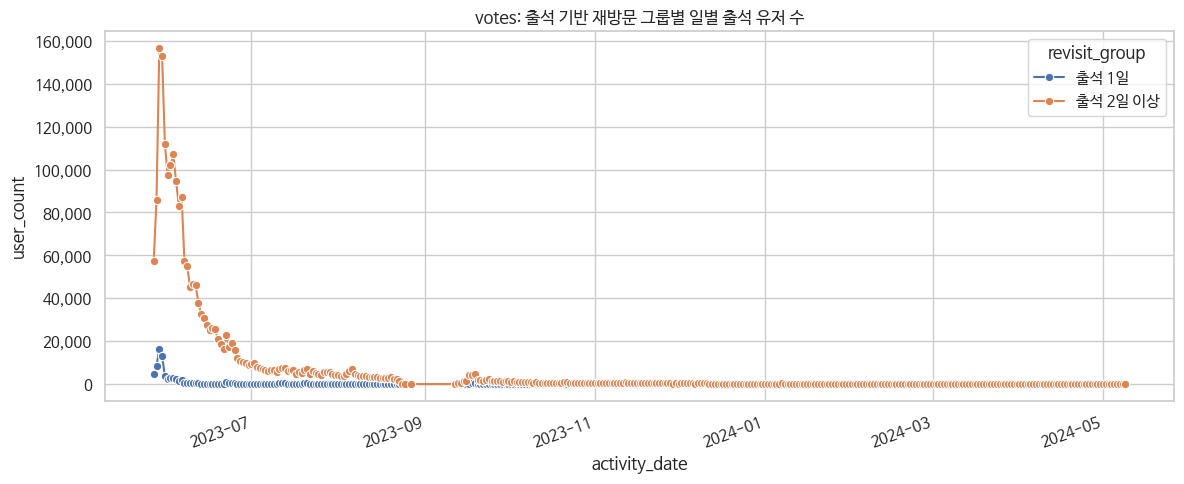

saved table preview: /content/votes_hackle_outputs/tables/02_votes_출석_일별_표.csv


#### votes 출석 일별 표

,activity_date,revisit_group,user_count
0,2023-05-27,출석 1일,4893
1,2023-05-27,출석 2일 이상,57524
2,2023-05-28,출석 1일,8552
3,2023-05-28,출석 2일 이상,85668
4,2023-05-29,출석 1일,16205
5,2023-05-29,출석 2일 이상,156631
6,2023-05-30,출석 1일,13069
7,2023-05-30,출석 2일 이상,152983
8,2023-05-31,출석 2일 이상,111971
9,2023-05-31,출석 1일,3742


### votes 결제 시계열
- **조건**: accounts_paymenthistory.created_at 기준 일별 결제 건수와 결제 유저 수
- **의미**: 결제 활동이 특정 날짜에 집중되는지 확인합니다.

saved figure: /content/votes_hackle_outputs/figures/02_votes_payment_daily.png


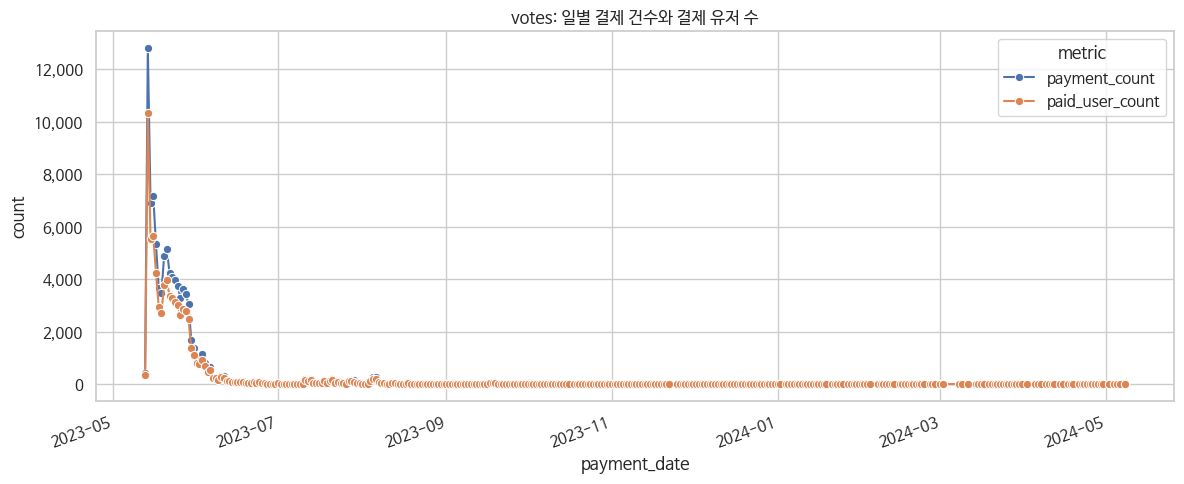

saved table preview: /content/votes_hackle_outputs/tables/03_votes_결제_일별_표.csv


#### votes 결제 일별 표

,payment_date,payment_count,paid_user_count
0,2023-05-13,421,362
1,2023-05-14,12802,10331
2,2023-05-15,6900,5536
3,2023-05-16,7163,5649
4,2023-05-17,5329,4244
5,2023-05-18,3676,2957
6,2023-05-19,3477,2726
7,2023-05-20,4875,3771
8,2023-05-21,5147,3957
9,2023-05-22,4229,3340


### votes 질문 기록 시계열
- **조건**: accounts_userquestionrecord.created_at 기준 일별 질문 기록 수, 열람 수, opened_times 합계
- **의미**: 질문 생성/열람 행동의 일별 흐름을 봅니다.

saved figure: /content/votes_hackle_outputs/figures/03_votes_question_daily.png


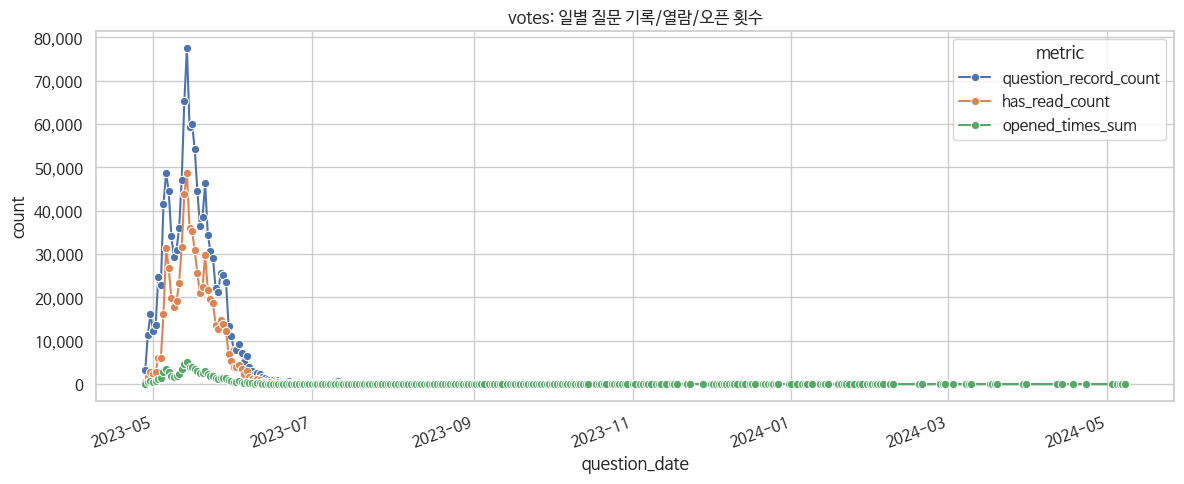

saved table preview: /content/votes_hackle_outputs/tables/04_votes_질문_기록_일별_표.csv


#### votes 질문 기록 일별 표

,question_date,question_record_count,question_user_count,question_chosen_user_count,has_read_count,opened_times_sum
0,2023-04-28,3173,125,181,457,104
1,2023-04-29,11405,221,371,1645,523
2,2023-04-30,16220,325,762,2709,629
3,2023-05-01,12274,325,973,2382,508
4,2023-05-02,13663,413,1307,2799,637
5,2023-05-03,24718,756,2025,6134,1281
6,2023-05-04,22814,820,2093,6134,1294
7,2023-05-05,41509,1248,3110,16082,2857
8,2023-05-06,48634,1375,3756,31311,3477
9,2023-05-07,44662,1355,4303,26842,2762


### hackle 시계열 지표
- **조건**: hackle_events 단일 테이블에서 event_datetime 기준 일별 이벤트 수와 세션 수
- **의미**: 앱 이벤트 로그의 전체 사용량 흐름을 session 기준으로 확인합니다.

saved figure: /content/votes_hackle_outputs/figures/04_hackle_daily.png


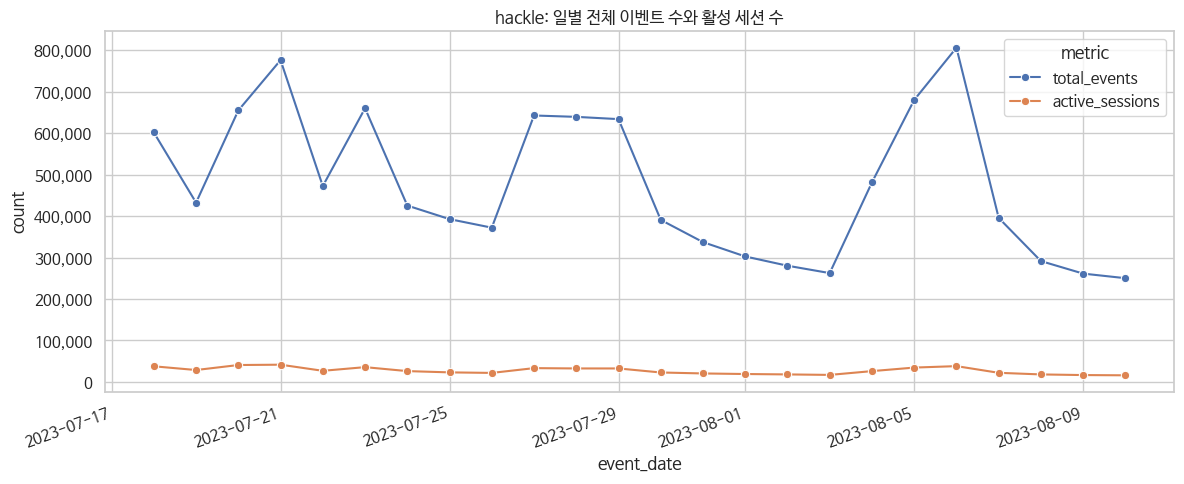

saved table preview: /content/votes_hackle_outputs/tables/05_hackle_일별_표.csv


#### hackle 일별 표

,event_date,total_events,click_appbar_alarm_center,click_attendance,click_bottom_navigation_timeline,click_friend_invite,click_invite_friend,click_notice_detail,click_question_open,click_question_share,view_timeline_tap,click_notice,active_sessions
0,2023-07-18,601647,16152,7688,31803,321,112,15867,49810,5998,154,1.0,37507
1,2023-07-19,432323,7280,6832,21502,144,48,7891,43146,5324,203,0.0,28536
2,2023-07-20,654795,18059,8914,37475,239,72,15989,53438,5188,3707,0.0,40601
3,2023-07-21,776150,19043,9252,38755,248,77,16890,53346,4931,105682,0.0,41398
4,2023-07-22,472335,7348,6470,21402,160,87,7593,37218,3531,58809,0.0,26653
5,2023-07-23,660058,16872,8104,34494,173,40,14911,48003,3887,90396,0.0,35480
6,2023-07-24,425333,6857,6621,19358,137,34,6889,34802,3323,52905,0.0,25937
7,2023-07-25,392567,5580,6080,16344,79,33,6040,30938,3260,45752,0.0,22856
8,2023-07-26,371971,4890,5681,14752,113,26,5464,27364,3014,41170,0.0,21566
9,2023-07-27,642616,16103,7227,29229,142,46,13684,39178,3894,77142,0.0,33098


In [39]:
note(
    "votes 시계열 지표",
    "출석, 결제, 질문 기록, 친구 요청을 날짜 단위로 집계",
    "votes DB에서 주요 행동이 시간에 따라 언제 많아졌는지 비교합니다.",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=attendance_daily, x="activity_date", y="user_count", hue="revisit_group", marker="o", ax=ax)
ax.set_title("votes: 출석 기반 재방문 그룹별 일별 출석 유저 수")
ax.set_xlabel("activity_date")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 출석 기반 재방문 그룹별 일별 출석 유저 수", "votes_attendance_daily")
show_table(attendance_daily, "votes 출석 일별 표")

note(
    "votes 결제 시계열",
    "accounts_paymenthistory.created_at 기준 일별 결제 건수와 결제 유저 수",
    "결제 활동이 특정 날짜에 집중되는지 확인합니다.",
)
payment_daily_long = payment_daily.melt(
    id_vars="payment_date",
    value_vars=["payment_count", "paid_user_count"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=payment_daily_long, x="payment_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("votes: 일별 결제 건수와 결제 유저 수")
ax.set_xlabel("payment_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 일별 결제 건수와 결제 유저 수", "votes_payment_daily")
show_table(payment_daily, "votes 결제 일별 표")

note(
    "votes 질문 기록 시계열",
    "accounts_userquestionrecord.created_at 기준 일별 질문 기록 수, 열람 수, opened_times 합계",
    "질문 생성/열람 행동의 일별 흐름을 봅니다.",
)
question_daily_long = question_daily.melt(
    id_vars="question_date",
    value_vars=["question_record_count", "has_read_count", "opened_times_sum"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=question_daily_long, x="question_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("votes: 일별 질문 기록/열람/오픈 횟수")
ax.set_xlabel("question_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 일별 질문 기록/열람/오픈 횟수", "votes_question_daily")
show_table(question_daily, "votes 질문 기록 일별 표")

note(
    "hackle 시계열 지표",
    "hackle_events 단일 테이블에서 event_datetime 기준 일별 이벤트 수와 세션 수",
    "앱 이벤트 로그의 전체 사용량 흐름을 session 기준으로 확인합니다.",
)
hackle_daily_long = hackle_daily.melt(
    id_vars="event_date",
    value_vars=["total_events", "active_sessions"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=hackle_daily_long, x="event_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("hackle: 일별 전체 이벤트 수와 활성 세션 수")
ax.set_xlabel("event_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("hackle: 일별 전체 이벤트 수와 활성 세션 수", "hackle_daily")
show_table(hackle_daily, "hackle 일별 표")

# ## 셀 1-9. 재방문

### 재방문 1: votes 출석 기반 재방문
- **조건**: accounts_attendance.attendance_date_list의 서로 다른 날짜 수가 2일 이상이면 재방문으로 분류
- **의미**: 출석 기록 기준으로 1일 출석 유저와 2일 이상 출석 유저의 규모를 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/05_revisit_votes_attendance.png


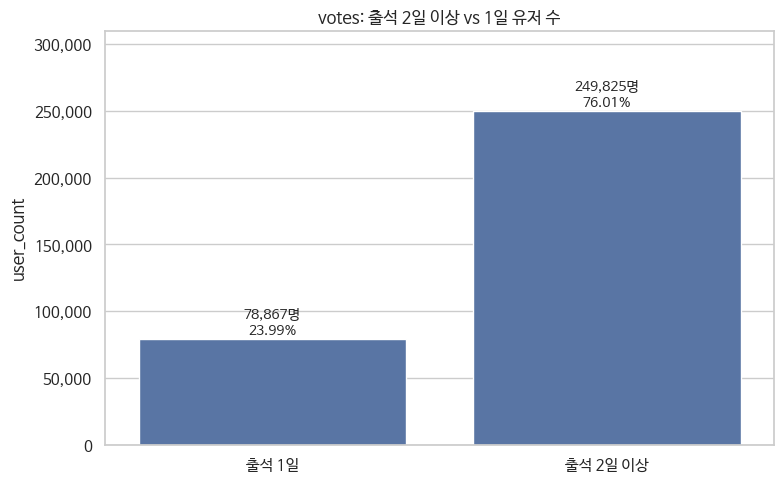

saved table preview: /content/votes_hackle_outputs/tables/06_votes_출석_재방문_요약.csv


#### votes 출석 재방문 요약

,group,user_count,ratio_pct,label
0,출석 1일,78867,23.99,"78,867명\n23.99%"
1,출석 2일 이상,249825,76.01,"249,825명\n76.01%"


### 재방문 2: hackle session 기준 반복 행동
- **조건**: session_id+날짜 기준으로 click_attendance 2회 이상/미만, 전체 로그 2회 이상/미만을 비교
- **의미**: 사람 기준이 아니라 세션-일 기준으로 반복 행동이 많은 세션을 봅니다.

saved figure: /content/votes_hackle_outputs/figures/06_revisit_hackle_session_day.png


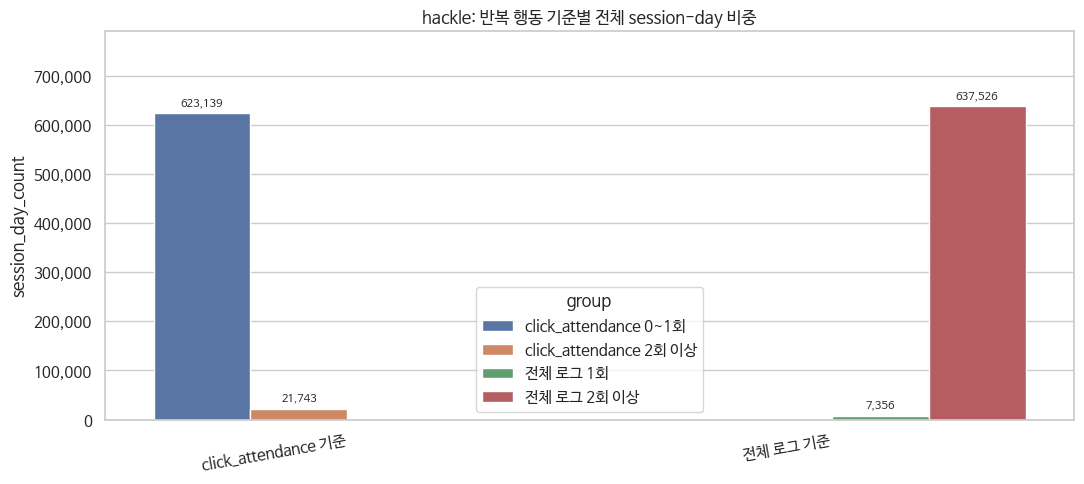

saved table preview: /content/votes_hackle_outputs/tables/07_hackle_재방문_반복_행동_요약.csv


#### hackle 재방문/반복 행동 요약

,criterion,group,session_day_count,ratio_pct
0,click_attendance 기준,click_attendance 0~1회,623139,96.63
1,click_attendance 기준,click_attendance 2회 이상,21743,3.37
2,전체 로그 기준,전체 로그 1회,7356,1.14
3,전체 로그 기준,전체 로그 2회 이상,637526,98.86


In [40]:
note(
    "재방문 1: votes 출석 기반 재방문",
    "accounts_attendance.attendance_date_list의 서로 다른 날짜 수가 2일 이상이면 재방문으로 분류",
    "출석 기록 기준으로 1일 출석 유저와 2일 이상 출석 유저의 규모를 비교합니다.",
)

attendance_revisit_summary = (
    attendance_user_agg.assign(group=lambda d: np.where(d["attendance_days"] >= 2, "출석 2일 이상", "출석 1일"))
    .groupby("group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)
attendance_revisit_summary = add_ratio_pct(attendance_revisit_summary, "user_count")
attendance_revisit_summary["label"] = attendance_revisit_summary.apply(
    lambda r: f"{r['user_count']:,.0f}명\n{r['ratio_pct']:.2f}%",
    axis=1,
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=attendance_revisit_summary, x="group", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_revisit_summary.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], row["label"], ha="center", va="bottom", fontsize=10)
ax.set_title("votes: 출석 2일 이상 vs 1일 유저 수")
ax.set_xlabel("")
ax.set_ylabel("user_count")
format_count_axis(ax)
save_mpl_fig("votes: 출석 2일 이상 vs 1일 유저 수", "revisit_votes_attendance")
show_table(attendance_revisit_summary, "votes 출석 재방문 요약")

note(
    "재방문 2: hackle session 기준 반복 행동",
    "session_id+날짜 기준으로 click_attendance 2회 이상/미만, 전체 로그 2회 이상/미만을 비교",
    "사람 기준이 아니라 세션-일 기준으로 반복 행동이 많은 세션을 봅니다.",
)
h = session_day.copy()
h["click_attendance_group"] = np.where(h["click_attendance_count"] >= 2, "click_attendance 2회 이상", "click_attendance 0~1회")
h["total_event_group"] = np.where(h["total_event_count"] >= 2, "전체 로그 2회 이상", "전체 로그 1회")
hackle_click_attendance_daily = (
    h.groupby(["event_date", "click_attendance_group"], as_index=False)
    .agg(session_day_count=("session_id", "nunique"))
    .rename(columns={"click_attendance_group": "group"})
)
hackle_click_attendance_daily["criterion"] = "click_attendance 기준"
hackle_total_event_daily = (
    h.groupby(["event_date", "total_event_group"], as_index=False)
    .agg(session_day_count=("session_id", "nunique"))
    .rename(columns={"total_event_group": "group"})
)
hackle_total_event_daily["criterion"] = "전체 로그 기준"
hackle_revisit_daily = pd.concat([hackle_click_attendance_daily, hackle_total_event_daily], ignore_index=True)
hackle_revisit_summary = (
    hackle_revisit_daily.groupby(["criterion", "group"], as_index=False)
    .agg(session_day_count=("session_day_count", "sum"))
)
hackle_revisit_summary = (
    hackle_revisit_summary.groupby("criterion", group_keys=False)
    .apply(lambda d: add_ratio_pct(d, "session_day_count"))
    .reset_index(drop=True)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=hackle_revisit_summary, x="criterion", y="session_day_count", hue="group", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 반복 행동 기준별 전체 session-day 비중")
ax.set_xlabel("")
ax.set_ylabel("session_day_count")
format_count_axis(ax)
rotate_xticks(ax, 10)
save_mpl_fig("hackle: 반복 행동 기준별 전체 session-day 비중", "revisit_hackle_session_day")
show_table(hackle_revisit_summary, "hackle 재방문/반복 행동 요약")


# ## 셀 1-10. 결제

### 결제 1: 결제 유저/미결제 유저/평균 결제 횟수
- **조건**: accounts_user 전체 user_id 중 accounts_paymenthistory에 등장한 유저를 결제 유저로 분류
- **의미**: 결제를 한 번이라도 한 유저 규모와 유저당 평균 결제 빈도를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/07_payment_paid_unpaid.png


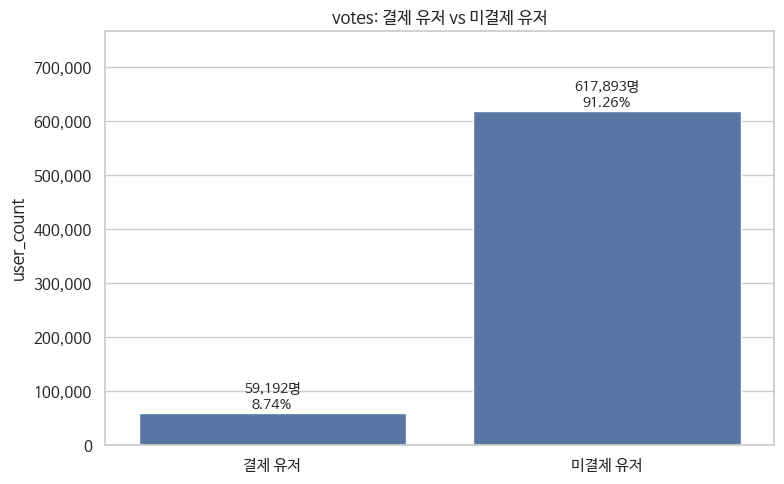

saved table preview: /content/votes_hackle_outputs/tables/08_결제_KPI_표.csv


#### 결제 KPI 표

,metric,value
0,결제 유저 수,59192.000000
1,미결제 유저 수,617893.000000
2,결제 유저당 평균 결제 시각 수,1.598341


### 결제 2: productId별 결제 분포
- **조건**: productId별 총 결제 건수, 서로 다른 결제 유저 수, 같은 유저가 같은 상품을 2회 이상 결제한 쌍 수
- **의미**: 어떤 상품이 많이 팔렸고, 같은 상품을 반복 구매한 유저가 얼마나 있는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/08_payment_product_distribution.png


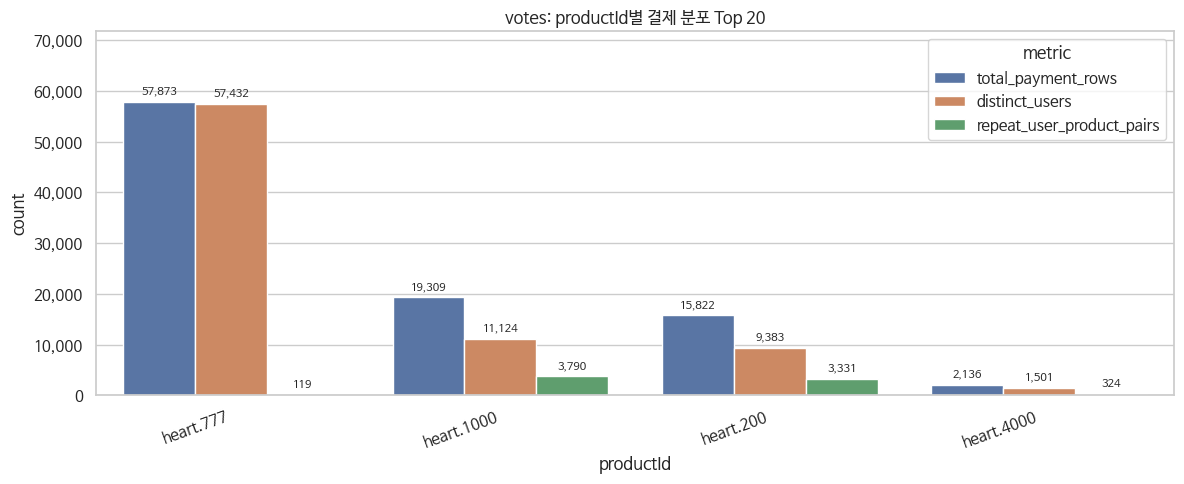

saved table preview: /content/votes_hackle_outputs/tables/09_productId별_결제_분포_표.csv


#### productId별 결제 분포 표

,productId,distinct_users,user_product_pairs,repeat_user_product_pairs,total_payment_rows
0,heart.777,57432,57432,119,57873
1,heart.1000,11124,11124,3790,19309
2,heart.200,9383,9383,3331,15822
3,heart.4000,1501,1501,324,2136


In [41]:
note(
    "결제 1: 결제 유저/미결제 유저/평균 결제 횟수",
    "accounts_user 전체 user_id 중 accounts_paymenthistory에 등장한 유저를 결제 유저로 분류",
    "결제를 한 번이라도 한 유저 규모와 유저당 평균 결제 빈도를 봅니다.",
)
paid_user_count = payment_user_agg["user_id"].nunique()
total_user_count = all_users["user_id"].nunique()
unpaid_user_count = total_user_count - paid_user_count
avg_payment_distinct_at = payment_user_agg["payment_distinct_at"].mean()
payment_user_status = pd.DataFrame({
    "group": ["결제 유저", "미결제 유저"],
    "user_count": [paid_user_count, unpaid_user_count],
})
payment_user_status = add_ratio_pct(payment_user_status, "user_count")
payment_kpi = pd.DataFrame({
    "metric": ["결제 유저 수", "미결제 유저 수", "결제 유저당 평균 결제 시각 수"],
    "value": [paid_user_count, unpaid_user_count, avg_payment_distinct_at],
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=payment_user_status, x="group", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in payment_user_status.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}명\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=10)
ax.set_title("votes: 결제 유저 vs 미결제 유저")
ax.set_xlabel("")
ax.set_ylabel("user_count")
format_count_axis(ax)
save_mpl_fig("votes: 결제 유저 vs 미결제 유저", "payment_paid_unpaid")
show_table(payment_kpi, "결제 KPI 표")

note(
    "결제 2: productId별 결제 분포",
    "productId별 총 결제 건수, 서로 다른 결제 유저 수, 같은 유저가 같은 상품을 2회 이상 결제한 쌍 수",
    "어떤 상품이 많이 팔렸고, 같은 상품을 반복 구매한 유저가 얼마나 있는지 봅니다.",
)
product_top = product_summary.head(TOP_N)
product_top_long = product_top.melt(
    id_vars="productId",
    value_vars=["total_payment_rows", "distinct_users", "repeat_user_product_pairs"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=product_top_long, x="productId", y="value", hue="metric", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title(f"votes: productId별 결제 분포 Top {TOP_N}")
ax.set_xlabel("productId")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig(f"votes: productId별 결제 분포 Top {TOP_N}", "payment_product_distribution")
show_table(product_summary, "productId별 결제 분포 표")

# ## 셀 1-11. 자발적 재참여/알림 관련 이벤트

### 자발적 재참여 1: 알림/타임라인 관련 event_key별 세션 분포
- **조건**: hackle_events에서 알림/타임라인 관련 event_key만 선택하고, session_id별 event_count 분포를 비교
- **의미**: 각 event_key가 세션에서 얼마나 반복적으로 발생하는지 봅니다. click_notice_detail이 알림 클릭 후 상세 진입에 가장 가까운 지표로 추정됩니다.

saved figure: /content/votes_hackle_outputs/figures/09_notice_event_distribution.png


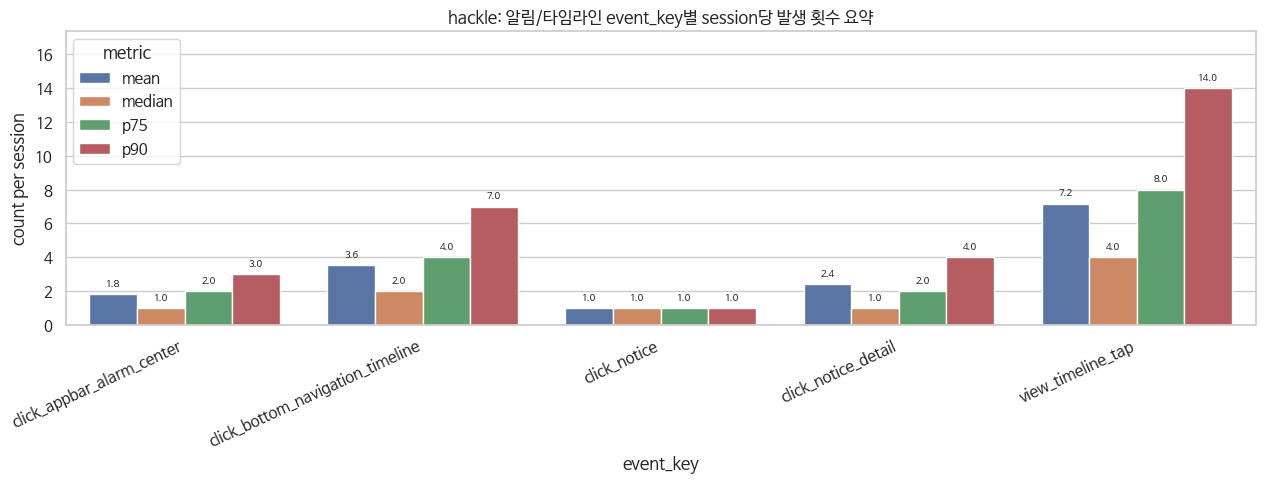

saved table preview: /content/votes_hackle_outputs/tables/10_알림_타임라인_event_key_분포_요약.csv


#### 알림/타임라인 event_key 분포 요약

,event_key,count,mean,median,p75,p90,max
0,click_appbar_alarm_center,140284,1.807341,1.0,2.0,3.0,3674
1,click_bottom_navigation_timeline,150463,3.562677,2.0,4.0,7.0,925
2,click_notice,1,1.000000,1.0,1.0,1.0,1
3,click_notice_detail,95541,2.400624,1.0,2.0,4.0,1492
4,view_timeline_tap,166495,7.174438,4.0,8.0,14.0,817


### 자발적 재참여 2: event_key 전체 발생 건수
- **조건**: 선택한 알림/타임라인 event_key별 전체 event_count 합계
- **의미**: 어떤 진입/클릭 행동이 가장 자주 발생했는지 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/10_notice_event_total.png


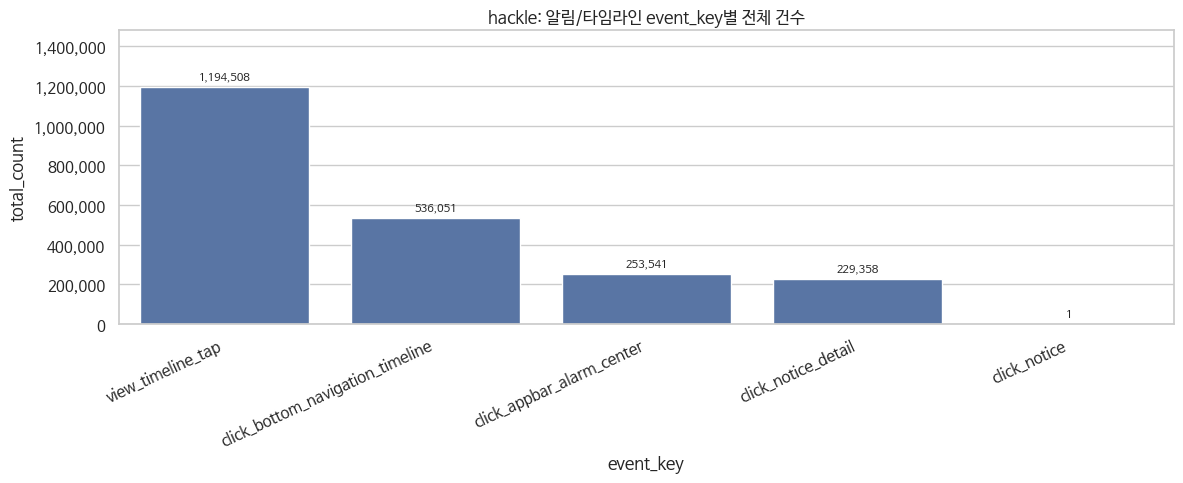

saved table preview: /content/votes_hackle_outputs/tables/11_알림_타임라인_event_key_전체_건수.csv


#### 알림/타임라인 event_key 전체 건수

,event_key,total_count
4,view_timeline_tap,1194508
1,click_bottom_navigation_timeline,536051
0,click_appbar_alarm_center,253541
3,click_notice_detail,229358
2,click_notice,1


### 자발적 재참여 3: 같은 session에서 다른 날짜에 2일 이상 발생
- **조건**: session_id+event_key 기준으로 서로 다른 event_date가 2일 이상이면 2일 이상 그룹으로 분류
- **의미**: 같은 세션 식별자에서 특정 알림/타임라인 행동이 날짜를 달리해 반복되는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/11_notice_event_2plus_days.png


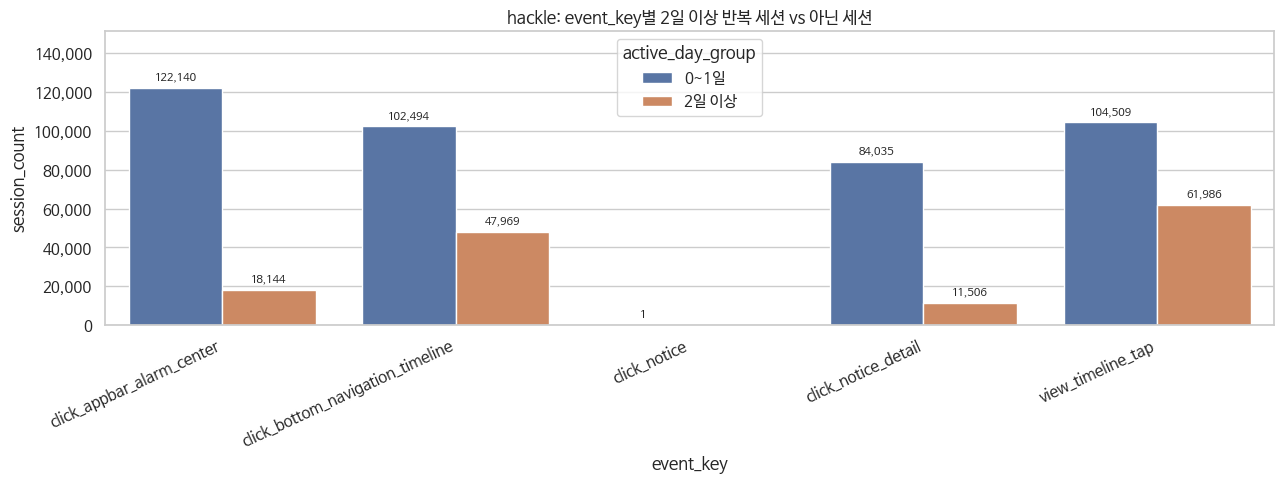

saved table preview: /content/votes_hackle_outputs/tables/12_알림_타임라인_2일_이상_반복_세션_표.csv


#### 알림/타임라인 2일 이상 반복 세션 표

,event_key,active_day_group,session_count
0,click_appbar_alarm_center,0~1일,122140
1,click_appbar_alarm_center,2일 이상,18144
2,click_bottom_navigation_timeline,0~1일,102494
3,click_bottom_navigation_timeline,2일 이상,47969
4,click_notice,0~1일,1
5,click_notice_detail,0~1일,84035
6,click_notice_detail,2일 이상,11506
7,view_timeline_tap,0~1일,104509
8,view_timeline_tap,2일 이상,61986


In [42]:
notice_session = event_session[event_session["event_key"].isin(NOTICE_EVENT_KEYS)].copy()

note(
    "자발적 재참여 1: 알림/타임라인 관련 event_key별 세션 분포",
    "hackle_events에서 알림/타임라인 관련 event_key만 선택하고, session_id별 event_count 분포를 비교",
    "각 event_key가 세션에서 얼마나 반복적으로 발생하는지 봅니다. click_notice_detail이 알림 클릭 후 상세 진입에 가장 가까운 지표로 추정됩니다.",
)
notice_distribution = distribution_summary(notice_session, "event_count", "event_key")
notice_distribution_long = notice_distribution.melt(
    id_vars="event_key",
    value_vars=["mean", "median", "p75", "p90"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=notice_distribution_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=7)
pad_y_axis(ax)
ax.set_title("hackle: 알림/타임라인 event_key별 session당 발생 횟수 요약")
ax.set_xlabel("event_key")
ax.set_ylabel("count per session")
rotate_xticks(ax, 25)
save_mpl_fig("hackle: 알림/타임라인 event_key별 session당 발생 횟수 요약", "notice_event_distribution")
show_table(notice_distribution, "알림/타임라인 event_key 분포 요약")

note(
    "자발적 재참여 2: event_key 전체 발생 건수",
    "선택한 알림/타임라인 event_key별 전체 event_count 합계",
    "어떤 진입/클릭 행동이 가장 자주 발생했는지 비교합니다.",
)
notice_total = notice_session.groupby("event_key", as_index=False).agg(total_count=("event_count", "sum")).sort_values("total_count", ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=notice_total, x="event_key", y="total_count", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 알림/타임라인 event_key별 전체 건수")
ax.set_xlabel("event_key")
ax.set_ylabel("total_count")
format_count_axis(ax)
rotate_xticks(ax, 25)
save_mpl_fig("hackle: 알림/타임라인 event_key별 전체 건수", "notice_event_total")
show_table(notice_total, "알림/타임라인 event_key 전체 건수")

note(
    "자발적 재참여 3: 같은 session에서 다른 날짜에 2일 이상 발생",
    "session_id+event_key 기준으로 서로 다른 event_date가 2일 이상이면 2일 이상 그룹으로 분류",
    "같은 세션 식별자에서 특정 알림/타임라인 행동이 날짜를 달리해 반복되는지 봅니다.",
)
notice_days = notice_session.copy()
notice_days["active_day_group"] = np.where(notice_days["active_days"] >= 2, "2일 이상", "0~1일")
notice_days_summary = notice_days.groupby(["event_key", "active_day_group"], as_index=False).agg(session_count=("session_id", "nunique"))
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=notice_days_summary, x="event_key", y="session_count", hue="active_day_group", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: event_key별 2일 이상 반복 세션 vs 아닌 세션")
ax.set_xlabel("event_key")
ax.set_ylabel("session_count")
format_count_axis(ax)
rotate_xticks(ax, 25)
save_mpl_fig("hackle: event_key별 2일 이상 반복 세션 vs 아닌 세션", "notice_event_2plus_days")
show_table(notice_days_summary, "알림/타임라인 2일 이상 반복 세션 표")

# ## 셀 1-12. 누적 활동일 수

### 누적 활동일 수 1: 비연속 활동일 수
- **조건**: accounts_attendance.attendance_date_list에서 서로 다른 날짜 수를 user_id별로 계산
- **의미**: 한 유저가 전체 기간 중 며칠 활동했는지 분포를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/12_activity_days_bucket.png


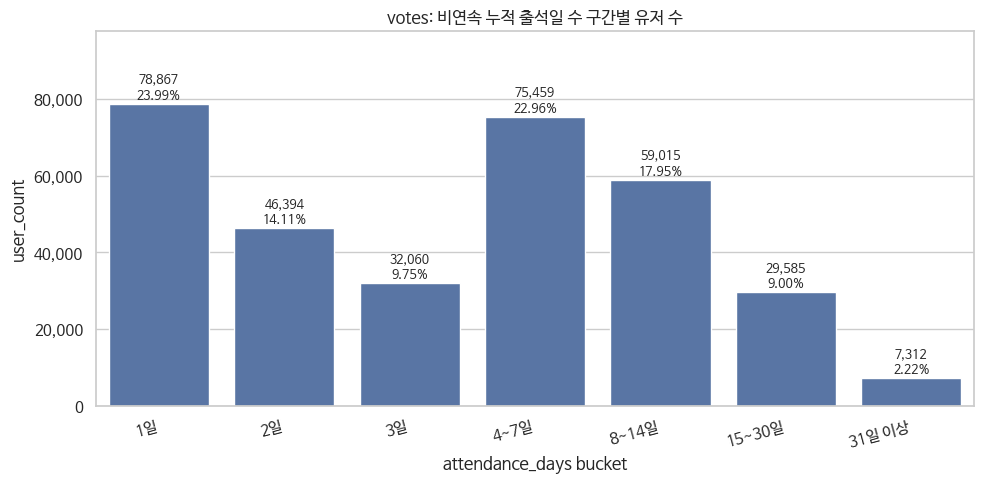

saved table preview: /content/votes_hackle_outputs/tables/13_비연속_누적_활동일_수_구간_요약.csv


#### 비연속 누적 활동일 수 구간 요약

,bucket,user_count,ratio_pct
0,1일,78867,23.99
1,2일,46394,14.11
2,3일,32060,9.75
3,4~7일,75459,22.96
4,8~14일,59015,17.95
5,15~30일,29585,9.00
6,31일 이상,7312,2.22


### 누적 활동일 수 2: 최장 연속 활동일 수
- **조건**: attendance_date_list에서 하루 차이로 이어지는 최장 연속 출석 구간을 user_id별로 계산
- **의미**: 끊기지 않고 연속적으로 활동한 기간이 긴 유저가 얼마나 있는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/13_activity_streak_bucket.png


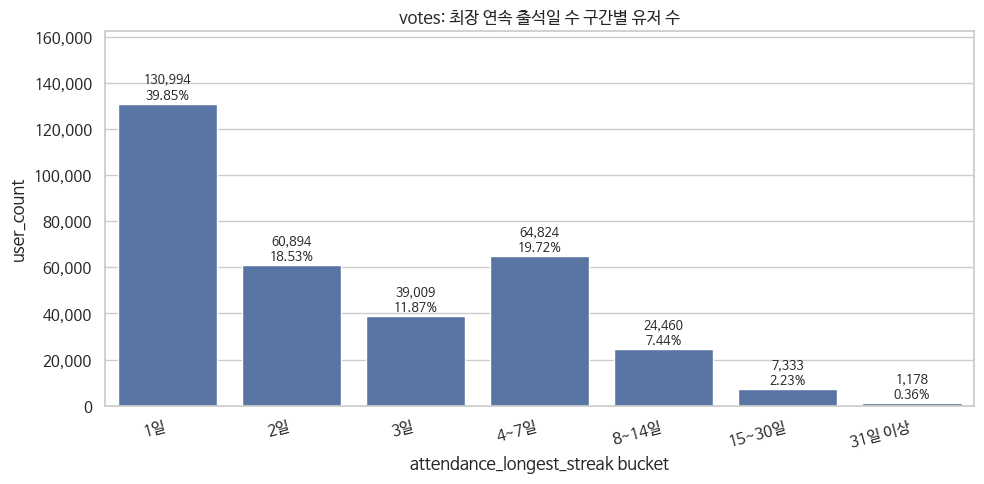

saved table preview: /content/votes_hackle_outputs/tables/14_최장_연속_활동일_수_구간_요약.csv


#### 최장 연속 활동일 수 구간 요약

,bucket,user_count,ratio_pct
0,1일,130994,39.85
1,2일,60894,18.53
2,3일,39009,11.87
3,4~7일,64824,19.72
4,8~14일,24460,7.44
5,15~30일,7333,2.23
6,31일 이상,1178,0.36


In [43]:
note(
    "누적 활동일 수 1: 비연속 활동일 수",
    "accounts_attendance.attendance_date_list에서 서로 다른 날짜 수를 user_id별로 계산",
    "한 유저가 전체 기간 중 며칠 활동했는지 분포를 봅니다.",
)
attendance_days_bucket = bucket_summary(
    attendance_user_agg,
    "attendance_days",
    bins=[0, 1, 2, 3, 7, 14, 30, np.inf],
    labels=["1일", "2일", "3일", "4~7일", "8~14일", "15~30일", "31일 이상"],
    count_name="user_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=attendance_days_bucket, x="bucket", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_days_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("votes: 비연속 누적 출석일 수 구간별 유저 수")
ax.set_xlabel("attendance_days bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 비연속 누적 출석일 수 구간별 유저 수", "activity_days_bucket")
show_table(attendance_days_bucket, "비연속 누적 활동일 수 구간 요약")

note(
    "누적 활동일 수 2: 최장 연속 활동일 수",
    "attendance_date_list에서 하루 차이로 이어지는 최장 연속 출석 구간을 user_id별로 계산",
    "끊기지 않고 연속적으로 활동한 기간이 긴 유저가 얼마나 있는지 봅니다.",
)
attendance_streak_bucket = bucket_summary(
    attendance_user_agg,
    "attendance_longest_streak",
    bins=[0, 1, 2, 3, 7, 14, 30, np.inf],
    labels=["1일", "2일", "3일", "4~7일", "8~14일", "15~30일", "31일 이상"],
    count_name="user_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=attendance_streak_bucket, x="bucket", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_streak_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("votes: 최장 연속 출석일 수 구간별 유저 수")
ax.set_xlabel("attendance_longest_streak bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 최장 연속 출석일 수 구간별 유저 수", "activity_streak_bucket")
show_table(attendance_streak_bucket, "최장 연속 활동일 수 구간 요약")

# ## 셀 1-13. 핵심 행동 반복

### 핵심 행동 반복 1: votes 질문 기록 기준
- **조건**: accounts_userquestionrecord에서 user_id 기준과 chosen_user_id 기준으로 record_count, has_read 합계, opened_times 합계를 비교
- **의미**: 질문을 던진/받은 역할별로 질문 수와 열람 행동이 어떻게 다른지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/14_core_question_role_mean.png


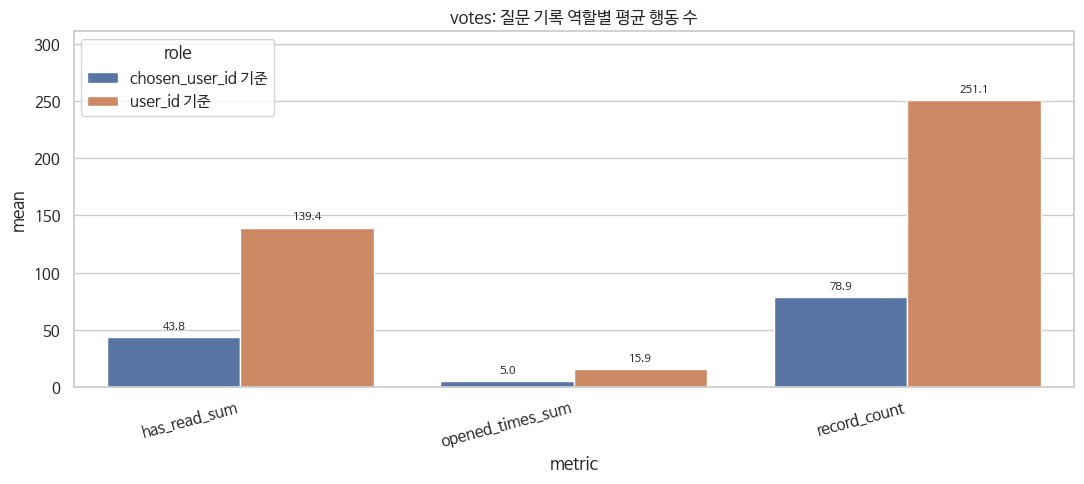

saved table preview: /content/votes_hackle_outputs/tables/15_질문_기록_역할별_요약.csv


#### 질문 기록 역할별 요약

,role,metric,mean,median,max
0,chosen_user_id 기준,has_read_sum,43.817646,6.0,912.0
1,chosen_user_id 기준,opened_times_sum,4.998185,0.0,101.0
2,chosen_user_id 기준,record_count,78.928951,15.0,1239.0
3,user_id 기준,has_read_sum,139.395958,101.0,1172.0
4,user_id 기준,opened_times_sum,15.900598,10.0,174.0
5,user_id 기준,record_count,251.094659,190.0,2786.0


### 핵심 행동 반복 2: hackle session 기준 질문 열람
- **조건**: session_id별 votes_count 최대값과 click_question_open 발생 횟수를 비교
- **의미**: 세션 기준으로 받은 투표/질문 규모와 질문 열람 행동이 같이 움직이는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/15_core_votes_open_heatmap.png


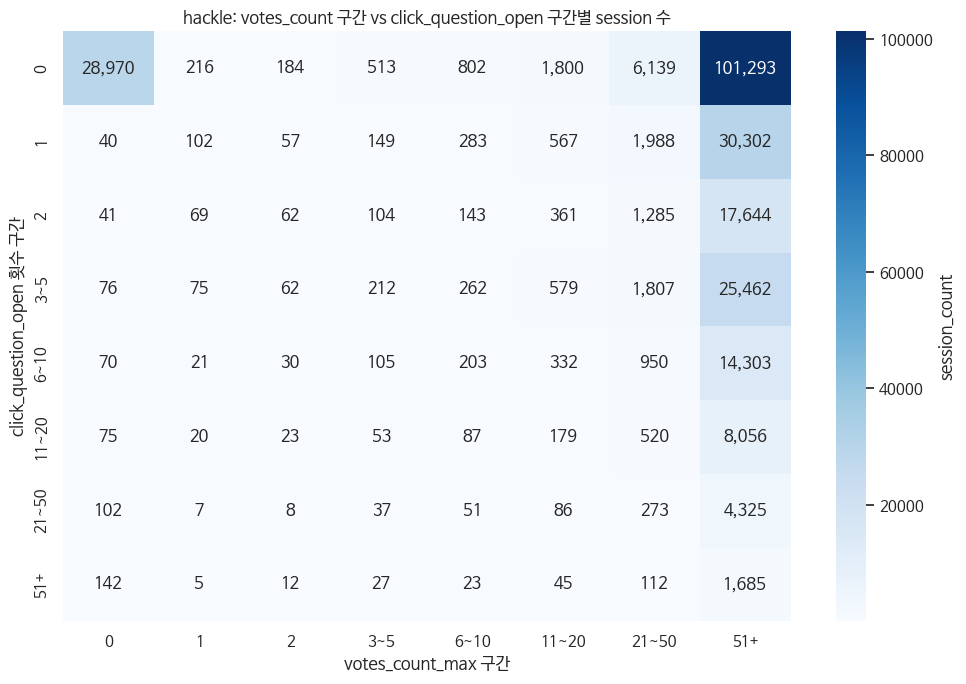

saved figure: /content/votes_hackle_outputs/figures/16_core_question_open_bucket.png


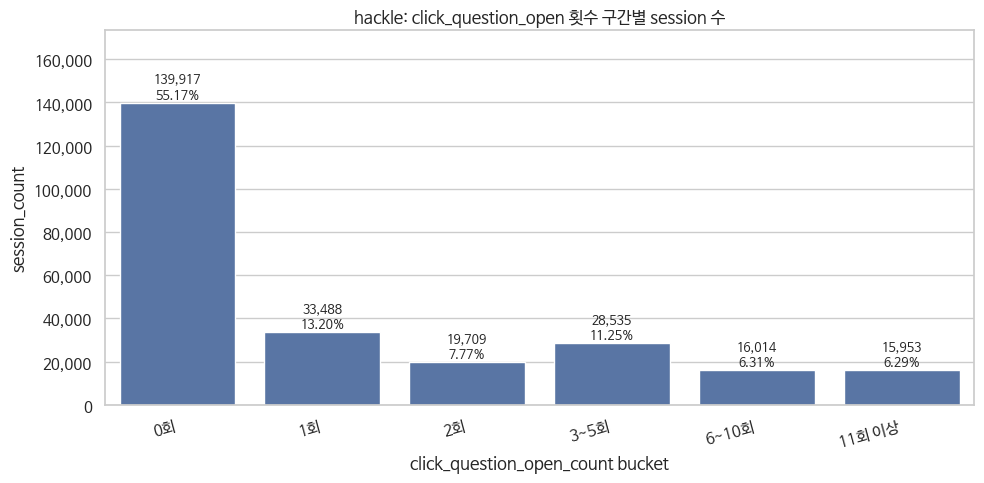

saved table preview: /content/votes_hackle_outputs/tables/16_hackle_click_question_open_분포_요약.csv


#### hackle click_question_open 분포 요약

,metric,count,mean,median,p75,p90,max
0,click_question_open_count,253616.0,3.220621,0.0,2.0,7.0,1515.0


In [44]:
note(
    "핵심 행동 반복 1: votes 질문 기록 기준",
    "accounts_userquestionrecord에서 user_id 기준과 chosen_user_id 기준으로 record_count, has_read 합계, opened_times 합계를 비교",
    "질문을 던진/받은 역할별로 질문 수와 열람 행동이 어떻게 다른지 봅니다.",
)
question_compare = pd.concat(
    [
        question_user_agg[["user_id", "question_user_record_count", "question_user_has_read_sum", "question_user_opened_times_sum"]]
        .rename(columns={
            "question_user_record_count": "record_count",
            "question_user_has_read_sum": "has_read_sum",
            "question_user_opened_times_sum": "opened_times_sum",
        })
        .assign(role="user_id 기준"),
        question_user_agg[["user_id", "question_chosen_record_count", "question_chosen_has_read_sum", "question_chosen_opened_times_sum"]]
        .rename(columns={
            "question_chosen_record_count": "record_count",
            "question_chosen_has_read_sum": "has_read_sum",
            "question_chosen_opened_times_sum": "opened_times_sum",
        })
        .assign(role="chosen_user_id 기준"),
    ],
    ignore_index=True,
)
question_compare_long = question_compare.melt(
    id_vars=["user_id", "role"],
    value_vars=["record_count", "has_read_sum", "opened_times_sum"],
    var_name="metric",
    value_name="value",
)
question_role_summary = question_compare_long.groupby(["role", "metric"], as_index=False).agg(
    mean=("value", "mean"),
    median=("value", "median"),
    max=("value", "max"),
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=question_role_summary, x="metric", y="mean", hue="role", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=8)
pad_y_axis(ax)
ax.set_title("votes: 질문 기록 역할별 평균 행동 수")
ax.set_xlabel("metric")
ax.set_ylabel("mean")
rotate_xticks(ax, 15)
save_mpl_fig("votes: 질문 기록 역할별 평균 행동 수", "core_question_role_mean")
show_table(question_role_summary, "질문 기록 역할별 요약")

note(
    "핵심 행동 반복 2: hackle session 기준 질문 열람",
    "session_id별 votes_count 최대값과 click_question_open 발생 횟수를 비교",
    "세션 기준으로 받은 투표/질문 규모와 질문 열람 행동이 같이 움직이는지 봅니다.",
)
core_relation = core_session.copy()
core_relation["votes_count_bucket"] = pd.cut(
    pd.to_numeric(core_relation["votes_count_max"], errors="coerce").fillna(0),
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0", "1", "2", "3~5", "6~10", "11~20", "21~50", "51+"],
)
core_relation["question_open_bucket"] = pd.cut(
    pd.to_numeric(core_relation["click_question_open_count"], errors="coerce").fillna(0),
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0", "1", "2", "3~5", "6~10", "11~20", "21~50", "51+"],
)
core_relation_summary = core_relation.groupby(["question_open_bucket", "votes_count_bucket"], observed=False, as_index=False).size().rename(columns={"size": "session_count"})
core_relation_pivot = core_relation_summary.pivot(index="question_open_bucket", columns="votes_count_bucket", values="session_count").fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    core_relation_pivot,
    annot=core_relation_pivot.applymap(lambda x: f"{x:,}"),
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "session_count"},
    ax=ax,
)
ax.set_title("hackle: votes_count 구간 vs click_question_open 구간별 session 수")
ax.set_xlabel("votes_count_max 구간")
ax.set_ylabel("click_question_open 횟수 구간")
save_mpl_fig("hackle: votes_count 구간 vs click_question_open 구간별 session 수", "core_votes_open_heatmap")

core_open_bucket = bucket_summary(
    core_session,
    "click_question_open_count",
    bins=[-0.1, 0, 1, 2, 5, 10, np.inf],
    labels=["0회", "1회", "2회", "3~5회", "6~10회", "11회 이상"],
    count_name="session_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=core_open_bucket, x="bucket", y="session_count", ax=ax)
pad_y_axis(ax)
for i, row in core_open_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["session_count"], f"{row['session_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("hackle: click_question_open 횟수 구간별 session 수")
ax.set_xlabel("click_question_open_count bucket")
ax.set_ylabel("session_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("hackle: click_question_open 횟수 구간별 session 수", "core_question_open_bucket")
show_table(distribution_summary(core_session, "click_question_open_count"), "hackle click_question_open 분포 요약")

# ## 셀 1-14. 추천/공유

### 추천/공유 1: votes 친구 요청
- **조건**: accounts_friendrequest에서 send_user_id별 서로 다른 receive_user_id 수와 receive_user_id별 서로 다른 send_user_id 수를 비교
- **의미**: 친구 요청을 많이 보낸 유저와 많이 받은 유저의 분포를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/17_share_friend_request_bucket.png


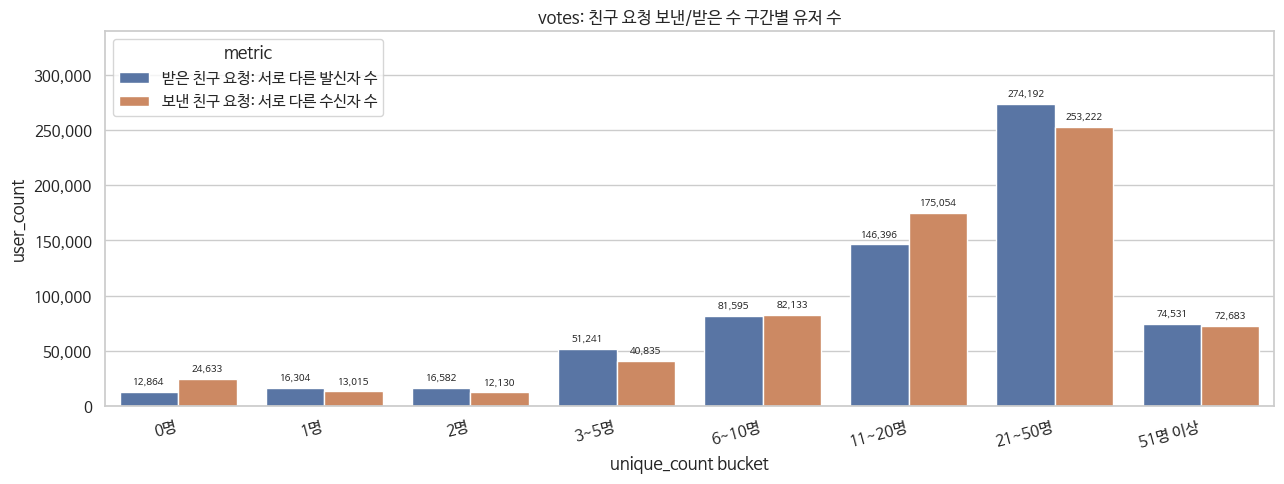

saved table preview: /content/votes_hackle_outputs/tables/17_친구_요청_구간별_요약.csv


#### 친구 요청 구간별 요약

,metric,count_bucket,user_count,ratio_pct
0,받은 친구 요청: 서로 다른 발신자 수,0명,12864,1.91
1,받은 친구 요청: 서로 다른 발신자 수,1명,16304,2.42
2,받은 친구 요청: 서로 다른 발신자 수,2명,16582,2.46
3,받은 친구 요청: 서로 다른 발신자 수,3~5명,51241,7.61
4,받은 친구 요청: 서로 다른 발신자 수,6~10명,81595,12.11
5,받은 친구 요청: 서로 다른 발신자 수,11~20명,146396,21.73
6,받은 친구 요청: 서로 다른 발신자 수,21~50명,274192,40.70
7,받은 친구 요청: 서로 다른 발신자 수,51명 이상,74531,11.06
8,보낸 친구 요청: 서로 다른 수신자 수,0명,24633,3.66
9,보낸 친구 요청: 서로 다른 수신자 수,1명,13015,1.93


saved table preview: /content/votes_hackle_outputs/tables/18_친구_요청_분포_요약.csv


#### 친구 요청 분포 요약

,metric,mean,median,max
0,받은 친구 요청: 서로 다른 발신자 수,25.290348,21.0,218.0
1,보낸 친구 요청: 서로 다른 수신자 수,25.290348,20.0,1549.0


### 추천/공유 2: hackle session 기준 초대/공유 이벤트
- **조건**: session_id별 click_invite_friend, click_friend_invite, click_question_share 발생 횟수
- **의미**: 세션 단위로 친구 초대/질문 공유 행동이 얼마나 발생하는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/18_share_hackle_event_total.png


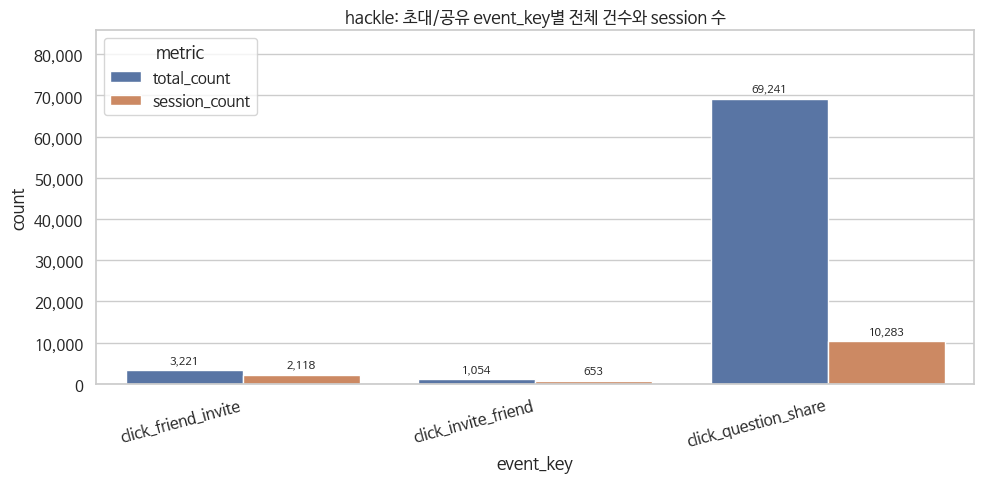

saved table preview: /content/votes_hackle_outputs/tables/19_hackle_초대_공유_요약.csv


#### hackle 초대/공유 요약

,event_key,total_count,session_count
0,click_friend_invite,3221,2118
1,click_invite_friend,1054,653
2,click_question_share,69241,10283


saved figure: /content/votes_hackle_outputs/figures/19_share_hackle_distribution.png


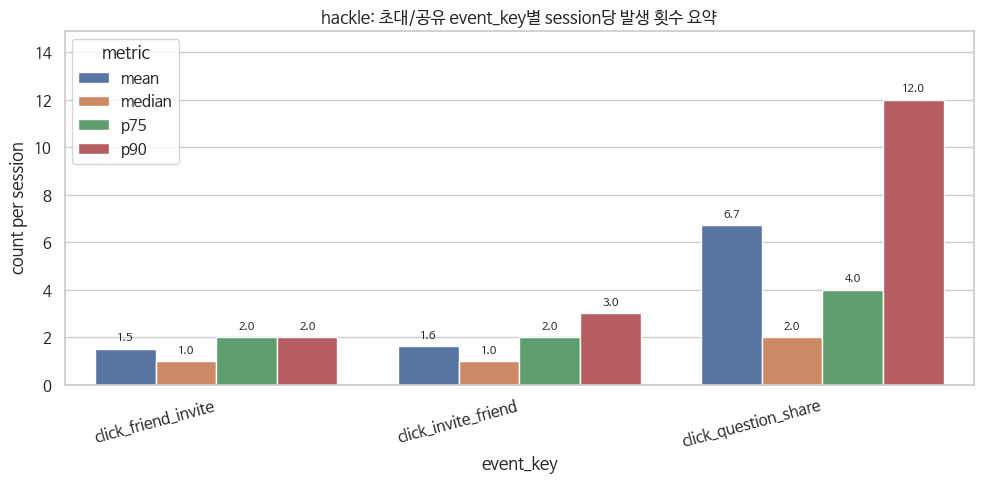

saved table preview: /content/votes_hackle_outputs/tables/20_hackle_초대_공유_session_분포_요약.csv


#### hackle 초대/공유 session 분포 요약

,event_key,count,mean,median,p75,p90,max
0,click_friend_invite,2118,1.520774,1.0,2.0,2.0,47
1,click_invite_friend,653,1.614089,1.0,2.0,3.0,42
2,click_question_share,10283,6.733541,2.0,4.0,12.0,436


In [45]:
note(
    "추천/공유 1: votes 친구 요청",
    "accounts_friendrequest에서 send_user_id별 서로 다른 receive_user_id 수와 receive_user_id별 서로 다른 send_user_id 수를 비교",
    "친구 요청을 많이 보낸 유저와 많이 받은 유저의 분포를 봅니다.",
)
friend_compare = pd.concat(
    [
        friend_user_agg[["user_id", "friend_sent_unique_receivers"]]
        .rename(columns={"friend_sent_unique_receivers": "unique_count"})
        .assign(metric="보낸 친구 요청: 서로 다른 수신자 수"),
        friend_user_agg[["user_id", "friend_received_unique_senders"]]
        .rename(columns={"friend_received_unique_senders": "unique_count"})
        .assign(metric="받은 친구 요청: 서로 다른 발신자 수"),
    ],
    ignore_index=True,
)
friend_compare["unique_count"] = pd.to_numeric(friend_compare["unique_count"], errors="coerce").fillna(0)
friend_compare["count_bucket"] = pd.cut(
    friend_compare["unique_count"],
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0명", "1명", "2명", "3~5명", "6~10명", "11~20명", "21~50명", "51명 이상"],
)
friend_bucket = friend_compare.groupby(["metric", "count_bucket"], observed=False, as_index=False).size().rename(columns={"size": "user_count"})
friend_bucket["ratio_pct"] = (friend_bucket["user_count"] / friend_bucket.groupby("metric")["user_count"].transform("sum") * 100).round(2)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=friend_bucket, x="count_bucket", y="user_count", hue="metric", ax=ax)
add_bar_labels(ax, fontsize=7)
pad_y_axis(ax)
ax.set_title("votes: 친구 요청 보낸/받은 수 구간별 유저 수")
ax.set_xlabel("unique_count bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 친구 요청 보낸/받은 수 구간별 유저 수", "share_friend_request_bucket")
show_table(friend_bucket, "친구 요청 구간별 요약")
show_table(friend_compare.groupby("metric", as_index=False).agg(mean=("unique_count", "mean"), median=("unique_count", "median"), max=("unique_count", "max")), "친구 요청 분포 요약")

note(
    "추천/공유 2: hackle session 기준 초대/공유 이벤트",
    "session_id별 click_invite_friend, click_friend_invite, click_question_share 발생 횟수",
    "세션 단위로 친구 초대/질문 공유 행동이 얼마나 발생하는지 봅니다.",
)
share_session = event_session[event_session["event_key"].isin(SHARE_EVENT_KEYS)].copy()
share_total = share_session.groupby("event_key", as_index=False).agg(total_count=("event_count", "sum"), session_count=("session_id", "nunique"))
share_total_long = share_total.melt(id_vars="event_key", value_vars=["total_count", "session_count"], var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=share_total_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 초대/공유 event_key별 전체 건수와 session 수")
ax.set_xlabel("event_key")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("hackle: 초대/공유 event_key별 전체 건수와 session 수", "share_hackle_event_total")
show_table(share_total, "hackle 초대/공유 요약")

share_distribution = distribution_summary(share_session, "event_count", "event_key")
share_distribution_long = share_distribution.melt(
    id_vars="event_key",
    value_vars=["mean", "median", "p75", "p90"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=share_distribution_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=8)
pad_y_axis(ax)
ax.set_title("hackle: 초대/공유 event_key별 session당 발생 횟수 요약")
ax.set_xlabel("event_key")
ax.set_ylabel("count per session")
rotate_xticks(ax, 15)
save_mpl_fig("hackle: 초대/공유 event_key별 session당 발생 횟수 요약", "share_hackle_distribution")
show_table(share_distribution, "hackle 초대/공유 session 분포 요약")

# ## 셀 1-15. GitHub 공유용 결과 묶기

In [46]:
# raw CSV는 포함하지 않습니다.
# GitHub에는 이 셀에서 만들어지는 `github_share` 폴더 또는 zip과 코드 파일을 올리면 됩니다.

# %%
SHARE_DIR = OUT_DIR / "github_share"
if SHARE_DIR.exists():
    shutil.rmtree(SHARE_DIR)
SHARE_DIR.mkdir(parents=True, exist_ok=True)

share_files = []
for source_dir in [FIG_DIR, TABLE_DIR]:
    for source_path in sorted(source_dir.glob("*")):
        if source_path.is_file():
            target_path = SHARE_DIR / source_dir.name / source_path.name
            target_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source_path, target_path)
            share_files.append(target_path)

summary_csv_names = [
    "votes_attendance_daily.csv",
    "votes_payment_daily.csv",
    "votes_product_summary.csv",
    "votes_question_daily.csv",
    "votes_friend_daily.csv",
    "hackle_daily.csv",
]
for filename in summary_csv_names:
    source_path = OUT_DIR / filename
    if source_path.exists():
        target_path = SHARE_DIR / "summary_csv" / filename
        target_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_path, target_path)
        share_files.append(target_path)

manifest_path = SHARE_DIR / "README_results.md"
with open(manifest_path, "w", encoding="utf-8") as f:
    f.write("# Votes + Hackle visualization results\n\n")
    f.write("이 폴더는 Colab에서 생성한 공유용 결과물입니다. 원본 raw CSV는 포함하지 않았습니다.\n\n")
    f.write("## Analysis Notes\n")
    if NOTES_FOR_README:
        for i, item in enumerate(NOTES_FOR_README, start=1):
            f.write(f"### {i}. {item['title']}\n")
            f.write(f"- 조건: {item['condition']}\n")
            f.write(f"- 의미: {item['meaning']}\n\n")
    else:
        f.write("- 저장된 note가 없습니다. 셀 08~14를 실행한 뒤 셀 15를 다시 실행하세요.\n\n")
    f.write("## Figures\n")
    for path in sorted((SHARE_DIR / "figures").glob("*")):
        f.write(f"- `figures/{path.name}`\n")
    f.write("\n## Table previews\n")
    for path in sorted((SHARE_DIR / "tables").glob("*.csv")):
        f.write(f"- `tables/{path.name}`\n")
    f.write("\n## Summary CSV\n")
    for path in sorted((SHARE_DIR / "summary_csv").glob("*.csv")):
        f.write(f"- `summary_csv/{path.name}`\n")

zip_path = shutil.make_archive(str(OUT_DIR / "github_share"), "zip", SHARE_DIR)

print("GitHub 공유용 폴더:", SHARE_DIR)
print("GitHub 공유용 zip:", zip_path)
print("그래프 PNG 수:", len(list((SHARE_DIR / "figures").glob("*.png"))))
print("표 preview CSV 수:", len(list((SHARE_DIR / "tables").glob("*.csv"))))
print("요약 CSV 수:", len(list((SHARE_DIR / "summary_csv").glob("*.csv"))))

GitHub 공유용 폴더: /content/votes_hackle_outputs/github_share
GitHub 공유용 zip: /content/votes_hackle_outputs/github_share.zip
그래프 PNG 수: 19
표 preview CSV 수: 20
요약 CSV 수: 6


# ## 셀 1-16. GitHub branch에 commit/push

In [48]:
# from google.colab import userdata
# from pathlib import Path
# import os

# token = userdata.get("GITHUB_TOKEN")
# if not token:
#     raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

# Path("/root/.netrc").write_text(
#     f"machine github.com\nlogin x-access-token\npassword {token}\n"
# )
# os.chmod("/root/.netrc", 0o600)

# %cd /content
# !rm -rf main_repo
# !git clone https://github.com/codeit-DA12-final3/main_repo.git
# %cd /content/main_repo
# !git fetch origin
# !git switch -c feature/suhyun-analysis --track origin/feature/suhyun-analysis

/content
Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 11.14 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/main_repo
Branch 'feature/suhyun-analysis' set up to track remote branch 'feature/suhyun-analysis' from 'origin'.
Switched to a new branch 'feature/suhyun-analysis'


In [49]:
# 전제:
# - Colab에서 `main_repo`를 clone했고, 현재 작업 branch로 switch 되어 있어야 합니다.
# - GitHub PAT는 Colab Secrets/Userdata에 `GITHUB_TOKEN` 이름으로 저장하세요.
# - raw CSV는 올리지 않고, 셀 15에서 만든 `github_share` 결과물과 현재 노트북/코드만 올립니다.

# %%
from google.colab import userdata
import subprocess

REPO_DIR = Path("/content/main_repo")
BRANCH_NAME = "feature/suhyun-analysis"  # 본인 branch 이름으로 수정 가능
GITHUB_REPO = "codeit-DA12-final3/main_repo"
GIT_USER_NAME = "sabrenyaa"
GIT_USER_EMAIL = "sabrenyaa@users.noreply.github.com"
COMMIT_MESSAGE = "Add votes and hackle visualization results"

if not REPO_DIR.exists():
    raise FileNotFoundError("REPO_DIR이 없습니다. 먼저 GitHub repo를 clone 했는지 확인하세요.")
if not SHARE_DIR.exists():
    raise FileNotFoundError("SHARE_DIR이 없습니다. 먼저 셀 15를 실행해서 GitHub 공유용 결과를 만들어주세요.")

token = userdata.get("GITHUB_TOKEN")
if not token:
    raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

def run_git(args, check=True):
    result = subprocess.run(
        args,
        cwd=REPO_DIR,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        safe_stderr = result.stderr.replace(token, "***TOKEN***")
        print(safe_stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"명령 실패: {' '.join(args)}")
    return result

target_dir = REPO_DIR / "analysis" / "suhyun_votes_hackle"
if target_dir.exists():
    shutil.rmtree(target_dir)
target_dir.mkdir(parents=True, exist_ok=True)

shutil.copytree(SHARE_DIR, target_dir / "github_share", dirs_exist_ok=True)

# 현재 Colab 노트북 파일명은 환경마다 다를 수 있어 결과 README를 중심으로 공유합니다.
# 별도 .ipynb를 repo에 넣고 싶으면 아래 NOTEBOOK_PATH를 본인 파일 경로로 수정하세요.
NOTEBOOK_PATH = None
if NOTEBOOK_PATH:
    notebook_path = Path(NOTEBOOK_PATH)
    if notebook_path.exists():
        shutil.copy2(notebook_path, target_dir / notebook_path.name)

run_git(["git", "config", "user.name", GIT_USER_NAME])
run_git(["git", "config", "user.email", GIT_USER_EMAIL])
switch_result = run_git(["git", "switch", BRANCH_NAME], check=False)
if switch_result.returncode != 0:
    run_git(["git", "switch", "-c", BRANCH_NAME])
run_git(["git", "remote", "set-url", "origin", f"https://{token}@github.com/{GITHUB_REPO}.git"])

run_git(["git", "add", str(target_dir.relative_to(REPO_DIR))])
status = run_git(["git", "status", "--short"], check=False)

if not status.stdout.strip():
    print("커밋할 변경사항이 없습니다.")
else:
    run_git(["git", "commit", "-m", COMMIT_MESSAGE])
    run_git(["git", "push", "origin", BRANCH_NAME])
    print(f"push 완료: {GITHUB_REPO} / {BRANCH_NAME}")

Your branch is up to date with 'origin/feature/suhyun-analysis'.

Already on 'feature/suhyun-analysis'

A  analysis/suhyun_votes_hackle/github_share/README_results.md
A  analysis/suhyun_votes_hackle/github_share/figures/01_votes_attendance_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/02_votes_payment_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/03_votes_question_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/04_hackle_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/05_revisit_votes_attendance.png
A  analysis/suhyun_votes_hackle/github_share/figures/06_revisit_hackle_session_day.png
A  analysis/suhyun_votes_hackle/github_share/figures/07_payment_paid_unpaid.png
A  analysis/suhyun_votes_hackle/github_share/figures/08_payment_product_distribution.png
A  analysis/suhyun_votes_hackle/github_share/figures/09_notice_event_distribution.png
A  analysis/suhyun_votes_hackle/github_share/figures/10_notice_event_total.png
A  analysi

In [ ]:
from pathlib import Path
import shutil
import subprocess
from google.colab import userdata

REPO_DIR = Path("/content/main_repo")
BRANCH_NAME = "feature/suhyun-analysis"
GITHUB_REPO = "codeit-DA12-final3/main_repo"

# 본인 노트북 경로로 수정
NOTEBOOK_PATH = "/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/Final_KimSuHyun.ipynb"

target_dir = REPO_DIR / "analysis" / "suhyun_votes_hackle"
target_dir.mkdir(parents=True, exist_ok=True)

notebook_path = Path(NOTEBOOK_PATH)
if not notebook_path.exists():
    raise FileNotFoundError(f"노트북 파일을 찾을 수 없습니다: {notebook_path}")

shutil.copy2(notebook_path, target_dir / notebook_path.name)

token = userdata.get("GITHUB_TOKEN")
if not token:
    raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

def run_git(args, check=True):
    result = subprocess.run(args, cwd=REPO_DIR, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr.replace(token, "***TOKEN***"))
    if check and result.returncode != 0:
        raise RuntimeError(f"명령 실패: {' '.join(args)}")
    return result

run_git(["git", "remote", "set-url", "origin", f"https://{token}@github.com/{GITHUB_REPO}.git"])
run_git(["git", "add", str((target_dir / notebook_path.name).relative_to(REPO_DIR))])

status = run_git(["git", "status", "--short"], check=False)

if not status.stdout.strip():
    print("추가로 커밋할 변경사항이 없습니다.")
else:
    run_git(["git", "commit", "-m", "Add analysis notebook"])
    run_git(["git", "push", "origin", BRANCH_NAME])
    print(f"노트북 push 완료: {GITHUB_REPO} / {BRANCH_NAME}")


# ## 셀2-1. Environment

In [ ]:
import ast
import os
import re
import shutil
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib import font_manager
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [ ]:
RUN_COLAB_SETUP = True
MOUNT_GOOGLE_DRIVE = True
INSTALL_KOREAN_FONT = True
SETUP_GITHUB_REPO = False

GITHUB_REPO = "codeit-DA12-final3/main_repo"
BRANCH_NAME = "feature/suhyun-analysis"
REPO_DIR = Path("/content/main_repo")


def running_in_colab():
    return "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ


if RUN_COLAB_SETUP and running_in_colab():
    if MOUNT_GOOGLE_DRIVE:
        try:
            from google.colab import drive

            drive.mount("/content/drive", force_remount=False)
        except Exception as e:
            print(f"[WARN] Google Drive mount skipped or failed: {e}")

    nanum_font_path = Path("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf")
    if INSTALL_KOREAN_FONT and not nanum_font_path.exists():
        print("Installing Nanum Korean fonts...")
        subprocess.run("apt-get update -qq", shell=True, check=False)
        subprocess.run("apt-get install -y fonts-nanum fonts-nanum-extra -qq", shell=True, check=False)
        subprocess.run("fc-cache -fv", shell=True, check=False)
        shutil.rmtree(Path.home() / ".cache" / "matplotlib", ignore_errors=True)

    if nanum_font_path.exists():
        font_manager.fontManager.addfont(str(nanum_font_path))
        font_name = font_manager.FontProperties(fname=str(nanum_font_path)).get_name()
        plt.rc("font", family=font_name)
        plt.rcParams["axes.unicode_minus"] = False

    if SETUP_GITHUB_REPO:
        try:
            from google.colab import userdata

            token = userdata.get("GITHUB_TOKEN")
            if not token:
                raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN이 없습니다.")

            Path("/root/.netrc").write_text(
                f"machine github.com\nlogin x-access-token\npassword {token}\n",
                encoding="utf-8",
            )
            os.chmod("/root/.netrc", 0o600)
            os.chdir("/content")

            if REPO_DIR.exists():
                shutil.rmtree(REPO_DIR)
            subprocess.run(["git", "clone", f"https://github.com/{GITHUB_REPO}.git", str(REPO_DIR)], check=True)
            subprocess.run(["git", "switch", "-c", BRANCH_NAME], cwd=REPO_DIR, check=True)
            print(f"GitHub repo ready: {REPO_DIR} / {BRANCH_NAME}")
        except Exception as e:
            print(f"[WARN] GitHub repo setup skipped or failed: {e}")

In [ ]:
# Google Drive folder that directly contains the raw CSV files.
DATA_DIR = Path("/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data")
if not (DATA_DIR / "accounts_user_master.csv").exists():
    raise FileNotFoundError(
        f"DATA_DIR에서 accounts_user_master.csv를 찾지 못했습니다: {DATA_DIR}\n"
        "Google Drive mount와 데이터 폴더 경로를 확인하세요."
    )
print("DATA_DIR =", DATA_DIR)

OUT_DIR = Path("/content/sender_behavior_axis_outputs")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
PROCESSED_DIR = OUT_DIR / "processed"

for path in [OUT_DIR, FIG_DIR, TABLE_DIR, PROCESSED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CHUNKSIZE = 1_000_000
RANDOM_STATE = 42

WINDOWS = {
    "d0": (0, 0),
    "d0_1": (0, 1),
    "d0_3": (0, 3),
    "d0_7": (0, 7),
    "d0_14": (0, 14),
    "d0_28": (0, 28),
    "d1_28": (1, 28),
    "d8_14": (8, 14),
    "d8_28": (8, 28),
}

FILES = {
    "users": DATA_DIR / "accounts_user_master.csv",
    "groups": DATA_DIR / "accounts_group_raw.csv",
    "user_properties": DATA_DIR / "user_properties_raw.csv",
    "attendance_long": DATA_DIR / "accounts_attendance_long.csv",
    "payment": DATA_DIR / "accounts_paymenthistory_raw.csv",
    "question_record": DATA_DIR / "accounts_userquestionrecord_raw.csv",
    "friend_request": DATA_DIR / "accounts_friendrequest_raw.csv",
    "point_history": DATA_DIR / "accounts_pointhistory_raw.csv",
    "hackle_properties": DATA_DIR / "hackle_properties_raw.csv",
    "hackle_events": DATA_DIR / "hackle_events_raw.csv",
}

RUN_HACKLE_SUPPLEMENT = True
RUN_GITHUB_PUSH = False

In [ ]:
# Review these after the Hackle event-key candidate table is generated.
HACKLE_QUESTION_START_KEYS = [
    "click_question_open",
    "view_questions_tap",
    "click_bottom_navigation_questions",
]
HACKLE_QUESTION_COMPLETE_KEYS = [
    "complete_question",
    "click_question_complete",
    "submit_question",
    "complete_vote",
    "click_vote_complete",
]
HACKLE_QUESTION_SKIP_KEYS = ["skip_question"]

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = selected_font
else:
    print("Korean font was not found. If labels break in Colab, install NanumGothic and rerun.")
plt.rcParams["axes.unicode_minus"] = False

for name, path in FILES.items():
    print(f"{name:18s}", "OK" if path.exists() else "MISSING", path)

# ## 셀 2-2. Helper Functions

In [7]:
_FIG_NO = 0
_TABLE_NO = 0
DUPLICATE_AUDIT_ROWS = []


def read_csv(path, **kwargs):
    return pd.read_csv(path, encoding="utf-8-sig", **kwargs)


def as_user_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def parse_list_len(value):
    if pd.isna(value):
        return 0
    if isinstance(value, list):
        return len(value)
    try:
        parsed = ast.literal_eval(str(value))
    except Exception:
        return 0
    return len(parsed) if isinstance(parsed, list) else 0


def clean_slug(value, fallback="output"):
    value = str(value or fallback)
    value = re.sub(r"[^\w가-힣]+", "_", value, flags=re.UNICODE).strip("_")
    return value[:90] or fallback


def save_table(df, title, filename=None, n=20):
    global _TABLE_NO
    _TABLE_NO += 1
    slug = clean_slug(filename or title, f"table_{_TABLE_NO:02d}")
    path = TABLE_DIR / f"{_TABLE_NO:02d}_{slug}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved table: {path}")
    display(Markdown(f"#### {title}"))
    display(df.head(n))
    return path


def save_processed(df, filename):
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved processed: {path}")
    return path


def save_fig(title, filename=None, fig=None, dpi=180):
    global _FIG_NO
    _FIG_NO += 1
    slug = clean_slug(filename or title, f"figure_{_FIG_NO:02d}")
    path = FIG_DIR / f"{_FIG_NO:02d}_{slug}.png"
    fig = fig or plt.gcf()
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved figure: {path}")
    plt.show()
    plt.close(fig)
    return path


def add_bar_labels(ax, decimals=1, suffix=""):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            if pd.isna(value):
                labels.append("")
            elif decimals == 0:
                labels.append(f"{value:,.0f}{suffix}")
            else:
                labels.append(f"{value:,.{decimals}f}{suffix}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def format_count_axis(ax, axis="y"):
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
    if axis in ["y", "both"]:
        ax.yaxis.set_major_formatter(formatter)
    if axis in ["x", "both"]:
        ax.xaxis.set_major_formatter(formatter)


def to_day(series):
    return pd.to_datetime(series, errors="coerce").dt.floor("D")


def add_signup_offset(df, user_col="user_id", date_col="event_date", users=None):
    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    out = df.merge(lookup, left_on=user_col, right_on="user_id", how="left", suffixes=("", "_signup"))
    if user_col != "user_id":
        out = out.drop(columns=["user_id"]).rename(columns={user_col: "user_id"})
    out["day_offset"] = (out[date_col] - out["signup_date"]).dt.days
    return out


def window_mask(series, window_name):
    start, end = WINDOWS[window_name]
    return series.between(start, end, inclusive="both")


def summarize_boolean_window(df, id_col, offset_col, value_col=None, prefix="metric"):
    base = df[[id_col, offset_col]].copy()
    if value_col:
        base[value_col] = pd.to_numeric(df[value_col], errors="coerce").fillna(0)
    parts = []
    for name, _window in WINDOWS.items():
        m = window_mask(base[offset_col], name)
        if value_col:
            agg = base.loc[m].groupby(id_col, as_index=False).agg(**{f"{prefix}_sum_{name}": (value_col, "sum")})
        else:
            agg = base.loc[m].groupby(id_col, as_index=False).size().rename(columns={"size": f"{prefix}_count_{name}"})
        parts.append(agg)
    if not parts:
        return pd.DataFrame(columns=[id_col])
    out = parts[0]
    for part in parts[1:]:
        out = out.merge(part, on=id_col, how="outer")
    return out


def aggregate_user_window_counts(df, id_col, offset_col, date_col, prefix):
    rows = []
    for name in WINDOWS:
        m = window_mask(df[offset_col], name)
        part = (
            df.loc[m]
            .groupby(id_col, as_index=False)
            .agg(
                **{
                    f"{prefix}_count_{name}": (date_col, "size"),
                    f"{prefix}_active_days_{name}": (date_col, "nunique"),
                }
            )
        )
        rows.append(part)
    out = rows[0]
    for part in rows[1:]:
        out = out.merge(part, on=id_col, how="outer")
    return out


def compact_numeric_fill(df):
    out = df.copy()
    numeric_cols = out.select_dtypes(include=["number", "bool"]).columns
    out[numeric_cols] = out[numeric_cols].fillna(0)
    return out


def winsorize_series(s, upper_q=0.99):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    upper = s.quantile(upper_q)
    if pd.isna(upper) or upper <= 0:
        return s
    return s.clip(upper=upper)


def make_axis_score(df, feature_cols, score_name):
    available = [c for c in feature_cols if c in df.columns]
    out = pd.Series(np.nan, index=df.index, name=score_name)
    if not available:
        print(f"[WARN] No columns available for {score_name}.")
        return out, []

    X = df[available].apply(pd.to_numeric, errors="coerce").fillna(0)
    for c in available:
        if X[c].nunique(dropna=True) > 2:
            X[c] = winsorize_series(X[c], 0.99)

    non_constant = [c for c in available if X[c].std(ddof=0) > 0]
    if not non_constant:
        return pd.Series(0.0, index=df.index, name=score_name), available

    scaled = StandardScaler().fit_transform(X[non_constant])
    out = pd.Series(scaled.mean(axis=1), index=df.index, name=score_name)
    return out, non_constant


def rate(x):
    return pd.to_numeric(x, errors="coerce").mean() * 100


def add_duplicate_audit(df, table_name, key_cols, stage, scope="loaded_frame"):
    """Record whether rows removed by key-based de-duplication are exact full-row duplicates."""
    key_cols = [c for c in key_cols if c in df.columns]
    full_dup_mask = df.duplicated(keep="first")

    if key_cols:
        key_dup_mask = df.duplicated(subset=key_cols, keep="first")
        duplicated_key_group_count = int(df.loc[df.duplicated(subset=key_cols, keep=False), key_cols].drop_duplicates().shape[0])
        key_duplicate_rows = int(key_dup_mask.sum())
        key_duplicate_not_full_rows = int((key_dup_mask & ~full_dup_mask).sum())
    else:
        key_duplicate_rows = 0
        duplicated_key_group_count = 0
        key_duplicate_not_full_rows = 0

    DUPLICATE_AUDIT_ROWS.append(
        {
            "table_name": table_name,
            "stage": stage,
            "scope": scope,
            "dedup_key": ", ".join(key_cols) if key_cols else "(none)",
            "row_count_before_dedup": int(len(df)),
            "full_row_duplicate_rows": int(full_dup_mask.sum()),
            "key_duplicate_rows_removed_by_drop_duplicates": key_duplicate_rows,
            "key_duplicate_rows_that_are_not_full_row_duplicates": key_duplicate_not_full_rows,
            "duplicated_key_group_count": duplicated_key_group_count,
            "full_duplicate_share_among_key_duplicates_pct": (
                round((key_duplicate_rows - key_duplicate_not_full_rows) / key_duplicate_rows * 100, 2)
                if key_duplicate_rows
                else np.nan
            ),
            "note": (
                "0이면 키 중복으로 제거될 행이 모두 전체 행 중복입니다."
                if key_duplicate_rows
                else "키 중복으로 제거될 행이 없습니다."
            ),
        }
    )

# ## 셀2-3. Load User Master and Define Populations

In [8]:
users = read_csv(
    FILES["users"],
    usecols=["id", "created_at", "friend_id_list", "group_id"],
    dtype={"id": "string", "group_id": "string"},
)
add_duplicate_audit(users, "accounts_user_master", ["id"], "before_drop_duplicates_id")
users = users.drop_duplicates(subset=["id"]).rename(columns={"id": "user_id"})
users["user_id"] = as_user_id(users["user_id"])
users["signup_at"] = pd.to_datetime(users["created_at"], errors="coerce")
users["signup_date"] = users["signup_at"].dt.floor("D")
users["friend_count"] = users["friend_id_list"].apply(parse_list_len)
users["group_id"] = pd.to_numeric(users["group_id"], errors="coerce").astype("Int64").astype("string")
users = users.dropna(subset=["user_id", "signup_date"])

groups = read_csv(FILES["groups"], usecols=["id", "school_id"], dtype={"id": "string", "school_id": "string"})
groups = groups.rename(columns={"id": "group_id", "school_id": "school_id_from_group"})
groups["group_id"] = pd.to_numeric(groups["group_id"], errors="coerce").astype("Int64").astype("string")
groups["school_id_from_group"] = pd.to_numeric(groups["school_id_from_group"], errors="coerce").astype("Int64").astype("string")
add_duplicate_audit(groups, "accounts_group_raw", ["group_id"], "before_drop_duplicates_group_id")
groups = groups.drop_duplicates(subset=["group_id"])

user_props = read_csv(FILES["user_properties"], usecols=["user_id", "school_id"], dtype={"user_id": "string", "school_id": "string"})
user_props["user_id"] = as_user_id(user_props["user_id"])
user_props["school_id_from_properties"] = pd.to_numeric(user_props["school_id"], errors="coerce").astype("Int64").astype("string")
add_duplicate_audit(user_props, "user_properties_raw", ["user_id"], "before_drop_duplicates_user_id")
user_props = user_props.drop(columns=["school_id"]).drop_duplicates(subset=["user_id"])

users = users.merge(groups, on="group_id", how="left").merge(user_props, on="user_id", how="left")
users["school_id"] = users["school_id_from_group"].fillna(users["school_id_from_properties"])

school_user_counts = (
    users.dropna(subset=["school_id"])
    .groupby("school_id", as_index=False)
    .agg(same_school_joined_user_count=("user_id", "nunique"))
)
users = users.merge(school_user_counts, on="school_id", how="left")
users["same_school_joined_user_count"] = users["same_school_joined_user_count"].fillna(0).astype(int)

users["home_entry_population"] = (
    (users["friend_count"] >= 4)
    & (users["same_school_joined_user_count"] >= 40)
)

population_funnel = pd.DataFrame(
    {
        "population": ["all_users", "has_signup_date", "home_entry_population"],
        "user_count": [
            users["user_id"].nunique(),
            users.dropna(subset=["signup_date"])["user_id"].nunique(),
            users.loc[users["home_entry_population"], "user_id"].nunique(),
        ],
    }
)
save_table(population_funnel, "Population funnel", "population_funnel")

preprocessing_checklist = pd.DataFrame(
    [
        {
            "step": "duplicate handling",
            "rule": "user, attendance-date, payment id, vote record id, and friend request id duplicates are removed before aggregation; duplicate_removal_audit.csv checks whether key duplicates are exact full-row duplicates.",
        },
        {
            "step": "missing handling",
            "rule": "rows missing required user_id/date keys are dropped; user-level missing metric values after merge are filled with 0.",
        },
        {
            "step": "outlier handling",
            "rule": "raw counts are preserved; count-like variables are winsorized at p99 only for EDA distribution plots and axis scoring.",
        },
        {
            "step": "main population",
            "rule": "home-entry users only: friend_count >= 4 and same_school_joined_user_count >= 40.",
        },
        {
            "step": "supplementary source",
            "rule": "Hackle is used only as a supplementary source when session_id can be mapped to user_id.",
        },
    ]
)
save_table(preprocessing_checklist, "Preprocessing checklist", "preprocessing_checklist", n=20)

save_processed(
    users[
        [
            "user_id",
            "signup_at",
            "signup_date",
            "friend_count",
            "school_id",
            "same_school_joined_user_count",
            "home_entry_population",
        ]
    ],
    "01_users_population.csv",
)

saved table: /content/sender_behavior_axis_outputs/tables/01_population_funnel.csv


#### Population funnel

,population,user_count
0,all_users,677085
1,has_signup_date,677085
2,home_entry_population,648611


saved table: /content/sender_behavior_axis_outputs/tables/02_preprocessing_checklist.csv


#### Preprocessing checklist

,step,rule
0,duplicate handling,"user, attendance-date, payment id, vote record..."
1,missing handling,rows missing required user_id/date keys are dr...
2,outlier handling,raw counts are preserved; count-like variables...
3,main population,home-entry users only: friend_count >= 4 and s...
4,supplementary source,Hackle is used only as a supplementary source ...


saved processed: /content/sender_behavior_axis_outputs/processed/01_users_population.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/01_users_population.csv')

# ## 04. Attendance-Based Revisit Metrics

In [9]:
attendance = read_csv(
    FILES["attendance_long"],
    usecols=["user_id", "attendance_date_list"],
    dtype={"user_id": "string"},
    parse_dates=["attendance_date_list"],
)
attendance = attendance.rename(columns={"attendance_date_list": "attendance_date"})
attendance["user_id"] = as_user_id(attendance["user_id"])
attendance["attendance_date"] = pd.to_datetime(attendance["attendance_date"], errors="coerce").dt.floor("D")
attendance = attendance.dropna(subset=["user_id", "attendance_date"])
add_duplicate_audit(attendance, "accounts_attendance_long", ["user_id", "attendance_date"], "before_drop_duplicates_user_date")
attendance = attendance.drop_duplicates(["user_id", "attendance_date"])
attendance = add_signup_offset(attendance, user_col="user_id", date_col="attendance_date", users=users)

attendance_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d1_28", "d8_28"]:
    m = window_mask(attendance["day_offset"], name)
    part = (
        attendance.loc[m]
        .groupby("user_id", as_index=False)
        .agg(**{f"attendance_days_{name}": ("attendance_date", "nunique")})
    )
    attendance_metrics = attendance_metrics.merge(part, on="user_id", how="outer")

attendance_metrics = compact_numeric_fill(attendance_metrics)
attendance_metrics["retention_d1_28"] = attendance_metrics["attendance_days_d1_28"] >= 1
attendance_metrics["retention_d8_28"] = attendance_metrics["attendance_days_d8_28"] >= 1

retention_check = pd.DataFrame(
    {
        "metric": ["retention_d1_28", "retention_d8_28"],
        "definition": ["D1-D28 기간 내 1회 이상 출석", "D8-D28 기간 내 1회 이상 출석"],
        "retained_user_count": [
            int(attendance_metrics["retention_d1_28"].sum()),
            int(attendance_metrics["retention_d8_28"].sum()),
        ],
        "total_user_count": [attendance_metrics["user_id"].nunique(), attendance_metrics["user_id"].nunique()],
    }
)
retention_check["rate_pct"] = (retention_check["retained_user_count"] / retention_check["total_user_count"] * 100).round(2)

save_table(retention_check, "Attendance-based retention check", "attendance_retention_check")
save_processed(attendance_metrics, "02_attendance_metrics.csv")

saved table: /content/sender_behavior_axis_outputs/tables/03_attendance_retention_check.csv


#### Attendance-based retention check

,metric,definition,retained_user_count,total_user_count,rate_pct
0,retention_d1_28,D1-D28 기간 내 1회 이상 출석,295889,677085,43.70
1,retention_d8_28,D8-D28 기간 내 1회 이상 출석,270788,677085,39.99


saved processed: /content/sender_behavior_axis_outputs/processed/02_attendance_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/02_attendance_metrics.csv')

# ## 05. Payment Outcomes

In [10]:
payment = read_csv(
    FILES["payment"],
    usecols=["id", "productId", "created_at", "user_id"],
    dtype={"id": "string", "productId": "string", "user_id": "string"},
)
add_duplicate_audit(payment, "accounts_paymenthistory_raw", ["id"], "before_drop_duplicates_id")
payment = payment.drop_duplicates(subset=["id"])
payment["user_id"] = as_user_id(payment["user_id"])
payment["payment_date"] = to_day(payment["created_at"])
payment = payment.dropna(subset=["user_id", "payment_date"])
payment = add_signup_offset(payment, user_col="user_id", date_col="payment_date", users=users)

payment_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_28", "d8_28"]:
    m = window_mask(payment["day_offset"], name)
    payment_part = (
        payment.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"payment_count_{name}": ("id", "size"),
                f"payment_active_days_{name}": ("payment_date", "nunique"),
                f"paid_flag_{name}": ("id", "size"),
            }
        )
    )
    payment_part[f"paid_flag_{name}"] = payment_part[f"paid_flag_{name}"] > 0
    payment_metrics = payment_metrics.merge(payment_part, on="user_id", how="left")

payment_metrics = compact_numeric_fill(payment_metrics)
for c in ["paid_flag_d0_28", "paid_flag_d8_28"]:
    if c in payment_metrics.columns:
        payment_metrics[c] = payment_metrics[c].astype(bool)

save_processed(payment_metrics, "03_payment_metrics.csv")


saved processed: /content/sender_behavior_axis_outputs/processed/03_payment_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/03_payment_metrics.csv')

# ## 06. Votes: Sender and Receiver Behavior

In [11]:
question = read_csv(
    FILES["question_record"],
    usecols=[
        "id",
        "status",
        "created_at",
        "chosen_user_id",
        "question_id",
        "user_id",
        "has_read",
        "answer_status",
        "answer_updated_at",
        "opened_times",
    ],
    dtype={
        "id": "string",
        "status": "string",
        "chosen_user_id": "string",
        "question_id": "string",
        "user_id": "string",
        "answer_status": "string",
    },
)
add_duplicate_audit(question, "accounts_userquestionrecord_raw", ["id"], "before_drop_duplicates_id")
question = question.drop_duplicates(subset=["id"])
question["user_id"] = as_user_id(question["user_id"])
question["chosen_user_id"] = as_user_id(question["chosen_user_id"])
question["created_date"] = to_day(question["created_at"])
question["answer_updated_date"] = to_day(question["answer_updated_at"])
question["has_read"] = pd.to_numeric(question["has_read"], errors="coerce").fillna(0).astype(int)
question["opened_times"] = pd.to_numeric(question["opened_times"], errors="coerce").fillna(0)
question["is_completed_vote"] = question["status"].fillna("").str.upper().eq("C")
question = question.dropna(subset=["user_id", "created_date"])

sent = add_signup_offset(
    question[
        [
            "id",
            "user_id",
            "chosen_user_id",
            "question_id",
            "status",
            "created_date",
            "is_completed_vote",
        ]
    ].copy(),
    user_col="user_id",
    date_col="created_date",
    users=users,
)

sender_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0", "d0_1", "d0_3", "d0_7", "d0_14", "d0_28"]:
    m = window_mask(sent["day_offset"], name)
    part = (
        sent.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"sent_vote_count_{name}": ("id", "size"),
                f"sent_vote_complete_count_{name}": ("is_completed_vote", "sum"),
                f"sent_vote_active_days_{name}": ("created_date", "nunique"),
                f"sent_vote_distinct_chosen_users_{name}": ("chosen_user_id", "nunique"),
                f"sent_vote_distinct_questions_{name}": ("question_id", "nunique"),
            }
        )
    )
    part[f"sent_vote_experience_{name}"] = part[f"sent_vote_count_{name}"] > 0
    sender_metrics = sender_metrics.merge(part, on="user_id", how="left")

sender_metrics = compact_numeric_fill(sender_metrics)
for c in [c for c in sender_metrics.columns if c.startswith("sent_vote_experience_")]:
    sender_metrics[c] = sender_metrics[c].astype(bool)

received = question.copy()
received["received_read_flag"] = (received["has_read"] > 0) | (received["opened_times"] > 0)
received["received_event_date"] = received["answer_updated_date"].fillna(received["created_date"])
received = received.dropna(subset=["chosen_user_id", "received_event_date"])
received = add_signup_offset(
    received[
        [
            "id",
            "chosen_user_id",
            "received_event_date",
            "received_read_flag",
            "has_read",
            "opened_times",
        ]
    ].copy(),
    user_col="chosen_user_id",
    date_col="received_event_date",
    users=users,
)

receiver_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_3", "d0_7", "d0_14", "d0_28"]:
    m = window_mask(received["day_offset"], name)
    part = (
        received.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"received_vote_count_{name}": ("id", "size"),
                f"received_vote_read_count_{name}": ("received_read_flag", "sum"),
                f"received_vote_opened_times_{name}": ("opened_times", "sum"),
                f"received_vote_active_days_{name}": ("received_event_date", "nunique"),
            }
        )
    )
    receiver_metrics = receiver_metrics.merge(part, on="user_id", how="left")

receiver_metrics = compact_numeric_fill(receiver_metrics)

save_processed(sender_metrics, "04_sender_vote_metrics.csv")
save_processed(receiver_metrics, "05_receiver_vote_metrics.csv")

saved processed: /content/sender_behavior_axis_outputs/processed/04_sender_vote_metrics.csv
saved processed: /content/sender_behavior_axis_outputs/processed/05_receiver_vote_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/05_receiver_vote_metrics.csv')

# ## 07. Friend Requests and Activity Days

In [12]:
def process_friend_request_metrics():
    metric_parts = []
    active_day_parts = []
    usecols = ["id", "status", "created_at", "updated_at", "receive_user_id", "send_user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    for i, chunk in enumerate(read_csv(FILES["friend_request"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        add_duplicate_audit(
            chunk,
            "accounts_friendrequest_raw",
            ["id"],
            "before_drop_duplicates_id",
            scope=f"chunk_{i}_within_chunk",
        )
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["send_user_id"] = as_user_id(chunk["send_user_id"])
        chunk["receive_user_id"] = as_user_id(chunk["receive_user_id"])
        chunk["created_date"] = to_day(chunk["created_at"])
        chunk["updated_date"] = to_day(chunk["updated_at"])
        chunk["accepted_flag"] = chunk["status"].fillna("").str.lower().isin(["accepted", "accept", "a", "c"])

        sent_chunk = (
            chunk.dropna(subset=["send_user_id", "created_date"])
            .merge(lookup, left_on="send_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"send_user_id": "user_id"})
        )
        sent_chunk["day_offset"] = (sent_chunk["created_date"] - sent_chunk["signup_date"]).dt.days

        recv_chunk = (
            chunk.dropna(subset=["receive_user_id", "created_date"])
            .merge(lookup, left_on="receive_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"receive_user_id": "user_id"})
        )
        recv_chunk["day_offset"] = (recv_chunk["created_date"] - recv_chunk["signup_date"]).dt.days

        for name in ["d0_7", "d0_28"]:
            sent_m = window_mask(sent_chunk["day_offset"], name)
            recv_m = window_mask(recv_chunk["day_offset"], name)
            sent_part = (
                sent_chunk.loc[sent_m]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_sent_count_{name}": ("id", "size"),
                        f"friend_sent_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            recv_part = (
                recv_chunk.loc[recv_m]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_received_count_{name}": ("id", "size"),
                        f"friend_received_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            metric_parts.append(sent_part.merge(recv_part, on="user_id", how="outer"))

        active_sent = sent_chunk.loc[window_mask(sent_chunk["day_offset"], "d0_28"), ["user_id", "created_date"]]
        active_sent = active_sent.rename(columns={"created_date": "activity_date"})

        recv_chunk["accept_day_offset"] = (recv_chunk["updated_date"] - recv_chunk["signup_date"]).dt.days
        active_accept = recv_chunk.loc[
            recv_chunk["accepted_flag"] & window_mask(recv_chunk["accept_day_offset"], "d0_28"),
            ["user_id", "updated_date"],
        ].rename(columns={"updated_date": "activity_date"})

        active_day_parts.append(pd.concat([active_sent, active_accept], ignore_index=True).drop_duplicates())

        if i % 5 == 0:
            print(f"friend_request processed chunks: {i}")

    metrics = pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
    active_days = pd.concat(active_day_parts, ignore_index=True).drop_duplicates()
    return metrics, active_days


friend_metrics, friend_activity_days = process_friend_request_metrics()
friend_metrics = compact_numeric_fill(friend_metrics)
save_processed(friend_metrics, "06_friend_request_metrics.csv")

friend_request processed chunks: 5
friend_request processed chunks: 10
friend_request processed chunks: 15
saved processed: /content/sender_behavior_axis_outputs/processed/06_friend_request_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/06_friend_request_metrics.csv')

# ## 08. Point History Activity Days

In [13]:
def process_point_activity_days():
    parts = []
    usecols = ["id", "delta_point", "created_at", "user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    metric_parts = []

    for i, chunk in enumerate(read_csv(FILES["point_history"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        add_duplicate_audit(
            chunk,
            "accounts_pointhistory_raw",
            ["id"],
            "before_drop_duplicates_id",
            scope=f"chunk_{i}_within_chunk",
        )
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["user_id"] = as_user_id(chunk["user_id"])
        chunk["point_date"] = to_day(chunk["created_at"])
        chunk["delta_point"] = pd.to_numeric(chunk["delta_point"], errors="coerce").fillna(0)
        chunk = chunk.dropna(subset=["user_id", "point_date"])
        chunk = chunk.merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["point_date"] - chunk["signup_date"]).dt.days
        chunk["point_use_flag"] = chunk["delta_point"] < 0

        in_28 = window_mask(chunk["day_offset"], "d0_28")
        parts.append(
            chunk.loc[in_28 & chunk["point_use_flag"], ["user_id", "point_date"]]
            .rename(columns={"point_date": "activity_date"})
        )

        in_7 = window_mask(chunk["day_offset"], "d0_7")
        metric_parts.append(
            chunk.loc[in_7]
            .groupby("user_id", as_index=False)
            .agg(
                point_event_count_d0_7=("id", "size"),
                point_use_count_d0_7=("point_use_flag", "sum"),
                point_delta_sum_d0_7=("delta_point", "sum"),
            )
        )

        if i % 5 == 0:
            print(f"point_history processed chunks: {i}")

    activity = pd.concat(parts, ignore_index=True).drop_duplicates() if parts else pd.DataFrame(columns=["user_id", "activity_date"])
    metrics = (
        pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
        if metric_parts
        else pd.DataFrame(columns=["user_id"])
    )
    return metrics, activity


point_metrics, point_activity_days = process_point_activity_days()
point_metrics = compact_numeric_fill(point_metrics)
save_processed(point_metrics, "07_point_metrics.csv")

saved processed: /content/sender_behavior_axis_outputs/processed/07_point_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/07_point_metrics.csv')

# ## 09. Cumulative Active Days

In [14]:
question_sent_activity = sent.loc[window_mask(sent["day_offset"], "d0_28"), ["user_id", "created_date"]].rename(
    columns={"created_date": "activity_date"}
)

received_read_activity = received.loc[
    window_mask(received["day_offset"], "d0_28") & received["received_read_flag"],
    ["user_id", "received_event_date"],
].rename(columns={"received_event_date": "activity_date"})

activity_days_long = pd.concat(
    [
        question_sent_activity,
        received_read_activity,
        friend_activity_days,
        point_activity_days,
    ],
    ignore_index=True,
).dropna(subset=["user_id", "activity_date"])
activity_days_long["activity_date"] = pd.to_datetime(activity_days_long["activity_date"], errors="coerce").dt.floor("D")
activity_days_long = activity_days_long.dropna(subset=["activity_date"])
add_duplicate_audit(
    activity_days_long,
    "derived_activity_days_long",
    ["user_id", "activity_date"],
    "before_drop_duplicates_user_activity_date",
)
activity_days_long = activity_days_long.drop_duplicates()
activity_days_long = add_signup_offset(activity_days_long, user_col="user_id", date_col="activity_date", users=users)

active_day_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_28", "d8_28"]:
    m = window_mask(activity_days_long["day_offset"], name)
    part = (
        activity_days_long.loc[m]
        .groupby("user_id", as_index=False)
        .agg(**{f"active_days_{name}": ("activity_date", "nunique")})
    )
    active_day_metrics = active_day_metrics.merge(part, on="user_id", how="left")

active_day_metrics = compact_numeric_fill(active_day_metrics)
active_day_definition = pd.DataFrame(
    [
        {
            "included_action": "보낸 투표",
            "source": "accounts_userquestionrecord_raw",
            "date_column": "created_at",
            "rule": "user_id 기준 투표 기록 발생일",
        },
        {
            "included_action": "받은 투표 열람",
            "source": "accounts_userquestionrecord_raw",
            "date_column": "answer_updated_at or created_at",
            "rule": "chosen_user_id 기준 has_read > 0 또는 opened_times > 0인 날",
        },
        {
            "included_action": "포인트 사용",
            "source": "accounts_pointhistory_raw",
            "date_column": "created_at",
            "rule": "delta_point < 0인 포인트 사용일",
        },
        {
            "included_action": "친구 요청",
            "source": "accounts_friendrequest_raw",
            "date_column": "created_at",
            "rule": "send_user_id 기준 친구 요청 발생일",
        },
        {
            "included_action": "친구 수락",
            "source": "accounts_friendrequest_raw",
            "date_column": "updated_at",
            "rule": "receive_user_id 기준 accepted status가 된 날",
        },
    ]
)
save_table(active_day_definition, "Cumulative active day included actions", "active_day_included_actions", n=20)
save_processed(active_day_metrics, "08_active_day_metrics.csv")

saved table: /content/sender_behavior_axis_outputs/tables/04_active_day_included_actions.csv


#### Cumulative active day included actions

,included_action,source,date_column,rule
0,보낸 투표,accounts_userquestionrecord_raw,created_at,user_id 기준 투표 기록 발생일
1,받은 투표 열람,accounts_userquestionrecord_raw,answer_updated_at or created_at,chosen_user_id 기준 has_read > 0 또는 opened_times...
2,포인트 사용,accounts_pointhistory_raw,created_at,delta_point < 0인 포인트 사용일
3,친구 요청,accounts_friendrequest_raw,created_at,send_user_id 기준 친구 요청 발생일
4,친구 수락,accounts_friendrequest_raw,updated_at,receive_user_id 기준 accepted status가 된 날


saved processed: /content/sender_behavior_axis_outputs/processed/08_active_day_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/08_active_day_metrics.csv')

# ## 10. Hackle Supplement: Question Start, Complete, Skip

In [15]:
def process_hackle_supplement():
    if not RUN_HACKLE_SUPPLEMENT:
        return pd.DataFrame({"user_id": users["user_id"].unique()})
    if not FILES["hackle_properties"].exists() or not FILES["hackle_events"].exists():
        print("[WARN] Hackle files are missing. Skipping Hackle supplement.")
        return pd.DataFrame({"user_id": users["user_id"].unique()})

    hprop = read_csv(
        FILES["hackle_properties"],
        usecols=["session_id", "user_id"],
        dtype={"session_id": "string", "user_id": "string"},
    )
    hprop["user_id"] = as_user_id(hprop["user_id"])
    hprop = hprop.dropna(subset=["session_id", "user_id"])
    add_duplicate_audit(hprop, "hackle_properties_raw", ["session_id"], "before_drop_duplicates_session_id")
    hprop = hprop.drop_duplicates(subset=["session_id"])
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    selected_keys = sorted(set(HACKLE_QUESTION_START_KEYS + HACKLE_QUESTION_COMPLETE_KEYS + HACKLE_QUESTION_SKIP_KEYS))
    candidate_counts = []
    metric_parts = []
    usecols = ["event_id", "event_datetime", "event_key", "session_id"]
    candidate_pattern = re.compile(r"question|vote|skip|complete", flags=re.IGNORECASE)

    for i, chunk in enumerate(read_csv(FILES["hackle_events"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk["event_key"] = chunk["event_key"].astype("string")

        candidate = chunk[chunk["event_key"].fillna("").str.contains(candidate_pattern, regex=True)]
        if not candidate.empty:
            candidate_counts.append(candidate.groupby("event_key", as_index=False).size())

        chunk = chunk[chunk["event_key"].isin(selected_keys)].copy()
        if chunk.empty:
            continue

        chunk["event_date"] = to_day(chunk["event_datetime"])
        chunk = chunk.dropna(subset=["event_date", "session_id"])
        chunk = chunk.merge(hprop, on="session_id", how="inner").merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["event_date"] - chunk["signup_date"]).dt.days
        chunk = chunk[window_mask(chunk["day_offset"], "d0_7")]
        if chunk.empty:
            continue

        chunk["hackle_question_start"] = chunk["event_key"].isin(HACKLE_QUESTION_START_KEYS)
        chunk["hackle_question_complete"] = chunk["event_key"].isin(HACKLE_QUESTION_COMPLETE_KEYS)
        chunk["hackle_question_skip"] = chunk["event_key"].isin(HACKLE_QUESTION_SKIP_KEYS)

        metric_parts.append(
            chunk.groupby("user_id", as_index=False).agg(
                hackle_question_start_count_d0_7=("hackle_question_start", "sum"),
                hackle_question_complete_count_d0_7=("hackle_question_complete", "sum"),
                hackle_question_skip_count_d0_7=("hackle_question_skip", "sum"),
                hackle_question_active_days_d0_7=("event_date", "nunique"),
            )
        )

        if i % 5 == 0:
            print(f"hackle_events processed chunks: {i}")

    if candidate_counts:
        candidates = (
            pd.concat(candidate_counts, ignore_index=True)
            .groupby("event_key", as_index=False)["size"]
            .sum()
            .rename(columns={"size": "event_count"})
            .sort_values("event_count", ascending=False)
        )
        save_table(candidates, "Hackle question/vote/skip/complete event-key candidates", "hackle_question_event_key_candidates", n=50)

    if metric_parts:
        metrics = pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
    else:
        metrics = pd.DataFrame({"user_id": users["user_id"].unique()})

    metrics = compact_numeric_fill(metrics)
    for c in [
        "hackle_question_start_count_d0_7",
        "hackle_question_complete_count_d0_7",
        "hackle_question_skip_count_d0_7",
        "hackle_question_active_days_d0_7",
    ]:
        if c not in metrics.columns:
            metrics[c] = 0

    denom = metrics["hackle_question_start_count_d0_7"].replace(0, np.nan)
    metrics["hackle_question_completion_rate_d0_7"] = (metrics["hackle_question_complete_count_d0_7"] / denom).fillna(0)
    metrics["hackle_question_skip_rate_d0_7"] = (metrics["hackle_question_skip_count_d0_7"] / denom).fillna(0)
    return metrics


hackle_metrics = process_hackle_supplement()
save_processed(hackle_metrics, "09_hackle_question_metrics.csv")

duplicate_audit = pd.DataFrame(DUPLICATE_AUDIT_ROWS)
if not duplicate_audit.empty:
    duplicate_audit = duplicate_audit.sort_values(["table_name", "stage", "scope"]).reset_index(drop=True)
    save_table(duplicate_audit, "Duplicate removal audit", "duplicate_removal_audit", n=100)
    save_processed(duplicate_audit, "duplicate_removal_audit.csv")

hackle_events processed chunks: 5
hackle_events processed chunks: 10
saved table: /content/sender_behavior_axis_outputs/tables/05_hackle_question_event_key_candidates.csv


#### Hackle question/vote/skip/complete event-key candidates

,event_key,event_count
2,click_question_open,816801
0,click_bottom_navigation_questions,769163
8,skip_question,454981
9,view_questions_tap,353400
4,click_question_start,220385
6,complete_question,154105
1,click_question_ask,136766
3,click_question_share,69241
5,complete_purchase,2201
7,complete_signup,974


saved processed: /content/sender_behavior_axis_outputs/processed/09_hackle_question_metrics.csv
saved table: /content/sender_behavior_axis_outputs/tables/06_duplicate_removal_audit.csv


#### Duplicate removal audit

,table_name,stage,scope,dedup_key,row_count_before_dedup,full_row_duplicate_rows,key_duplicate_rows_removed_by_drop_duplicates,key_duplicate_rows_that_are_not_full_row_duplicates,duplicated_key_group_count,full_duplicate_share_among_key_duplicates_pct,note
0,accounts_attendance_long,before_drop_duplicates_user_date,loaded_frame,"user_id, attendance_date",2222327,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
1,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_10_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
2,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_11_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
3,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_12_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
4,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_13_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
5,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_14_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
6,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_15_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
7,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_16_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
8,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_17_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
9,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_18_within_chunk,id,147175,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.


saved processed: /content/sender_behavior_axis_outputs/processed/duplicate_removal_audit.csv


# ## 11. Build Final User-Level Analysis Table

In [16]:
analysis_df = users[
    [
        "user_id",
        "signup_at",
        "signup_date",
        "friend_count",
        "school_id",
        "same_school_joined_user_count",
        "home_entry_population",
    ]
].copy()

for frame in [
    attendance_metrics,
    payment_metrics,
    sender_metrics,
    receiver_metrics,
    friend_metrics,
    point_metrics,
    active_day_metrics,
    hackle_metrics,
]:
    analysis_df = analysis_df.merge(frame, on="user_id", how="left")

analysis_df = compact_numeric_fill(analysis_df)

bool_cols = [
    "home_entry_population",
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
]
bool_cols += [c for c in analysis_df.columns if c.startswith("sent_vote_experience_")]
for c in bool_cols:
    if c in analysis_df.columns:
        analysis_df[c] = analysis_df[c].astype(bool)

analysis_df["sender_group"] = np.where(
    analysis_df["sent_vote_experience_d0_7"],
    "보낸 투표 경험 유",
    "보낸 투표 경험 무",
)

save_processed(analysis_df, "10_sender_behavior_analysis_user_level.csv")

saved processed: /content/sender_behavior_axis_outputs/processed/10_sender_behavior_analysis_user_level.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/10_sender_behavior_analysis_user_level.csv')

# ## 12. Result Table: Sender Experience Groups

In [17]:
def summarize_sender_groups(df, base_filter, base_name):
    base = df.loc[base_filter].copy()
    summary = (
        base.groupby("sender_group", as_index=False)
        .agg(
            user_count=("user_id", "nunique"),
            retention_d1_28_rate=("retention_d1_28", rate),
            retention_d8_28_rate=("retention_d8_28", rate),
            payment_d0_28_count_mean=("payment_count_d0_28", "mean"),
            payment_d8_28_count_mean=("payment_count_d8_28", "mean"),
            payment_d0_28_rate=("paid_flag_d0_28", rate),
            payment_d8_28_rate=("paid_flag_d8_28", rate),
            active_days_d0_28_mean=("active_days_d0_28", "mean"),
            active_days_d8_28_mean=("active_days_d8_28", "mean"),
            sent_vote_count_d0_7_mean=("sent_vote_count_d0_7", "mean"),
            sent_vote_count_d0_3_mean=("sent_vote_count_d0_3", "mean"),
        )
    )
    summary.insert(0, "analysis_axis", "발신 행동축")
    summary.insert(1, "core_variable", "D0-D7 보낸 투표 경험")
    summary.insert(2, "base_population", base_name)

    with_exp = summary.loc[summary["sender_group"].eq("보낸 투표 경험 유")]
    without_exp = summary.loc[summary["sender_group"].eq("보낸 투표 경험 무")]
    interpretation = {}
    if not with_exp.empty and not without_exp.empty:
        a = with_exp.iloc[0]
        b = without_exp.iloc[0]
        interpretation["보낸 투표 경험 유"] = (
            f"경험 무 대비 재방문율 D1-D28 {a['retention_d1_28_rate'] - b['retention_d1_28_rate']:+.1f}%p, "
            f"재방문율 D8-D28 {a['retention_d8_28_rate'] - b['retention_d8_28_rate']:+.1f}%p, "
            f"결제율 D0-D28 {a['payment_d0_28_rate'] - b['payment_d0_28_rate']:+.1f}%p, "
            f"결제율 D8-D28 {a['payment_d8_28_rate'] - b['payment_d8_28_rate']:+.1f}%p, "
            f"활동일 D0-D28 {a['active_days_d0_28_mean'] - b['active_days_d0_28_mean']:+.2f}일 차이."
        )
        interpretation["보낸 투표 경험 무"] = "비교 기준 그룹."
    summary["interpretation"] = summary["sender_group"].map(interpretation).fillna("")

    rate_cols = [c for c in summary.columns if c.endswith("_rate")]
    mean_cols = [c for c in summary.columns if c.endswith("_mean")]
    summary[rate_cols] = summary[rate_cols].round(2)
    summary[mean_cols] = summary[mean_cols].round(2)
    return summary.sort_values("sender_group")


home_summary = summarize_sender_groups(
    analysis_df,
    analysis_df["home_entry_population"],
    "home_entry_population: friend_count >= 4 and same_school_joined_user_count >= 40",
)

save_table(home_summary, "Main result table by sender experience - home-entry population", "main_result_sender_experience_home")

saved table: /content/sender_behavior_axis_outputs/tables/07_main_result_sender_experience_home.csv


#### Main result table by sender experience - home-entry population

,analysis_axis,core_variable,base_population,sender_group,user_count,retention_d1_28_rate,retention_d8_28_rate,payment_d0_28_count_mean,payment_d8_28_count_mean,payment_d0_28_rate,payment_d8_28_rate,active_days_d0_28_mean,active_days_d8_28_mean,sent_vote_count_d0_7_mean,sent_vote_count_d0_3_mean,interpretation
0,발신 행동축,D0-D7 보낸 투표 경험,home_entry_population: friend_count >= 4 and s...,보낸 투표 경험 유,648611,45.34,41.54,0.13,0.04,100.0,100.0,5.32,1.67,1.38,0.9,


PosixPath('/content/sender_behavior_axis_outputs/tables/07_main_result_sender_experience_home.csv')

# ## 13. EDA Visualizations

saved figure: /content/sender_behavior_axis_outputs/figures/01_eda_population_funnel.png


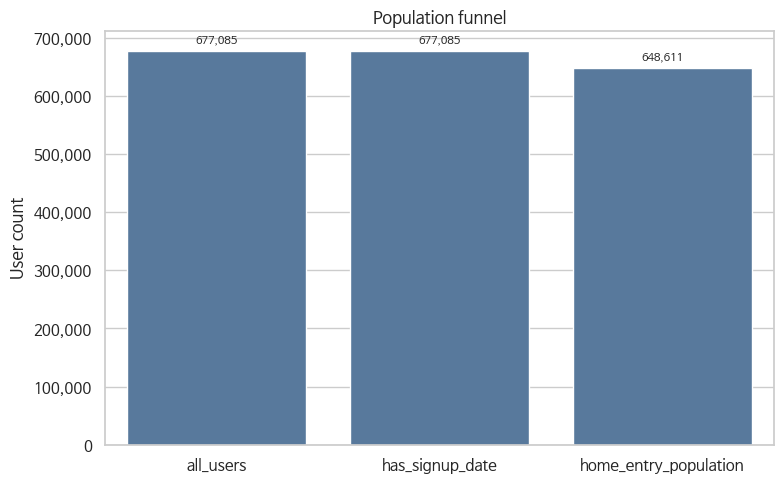

saved figure: /content/sender_behavior_axis_outputs/figures/02_eda_sender_group_size.png


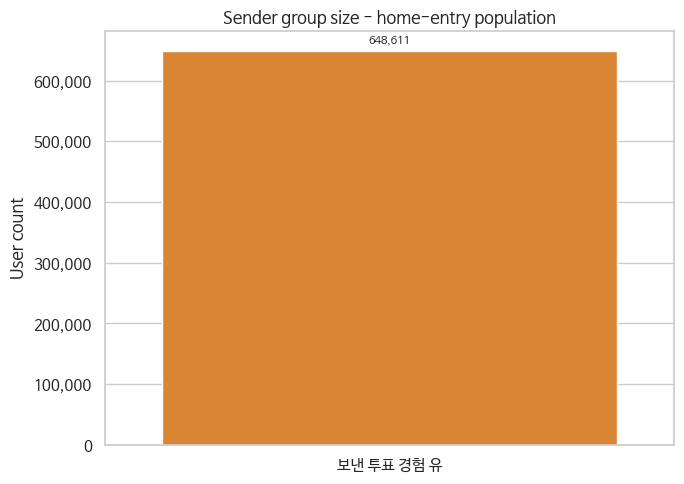

saved figure: /content/sender_behavior_axis_outputs/figures/03_eda_outcome_rates_by_sender_group.png


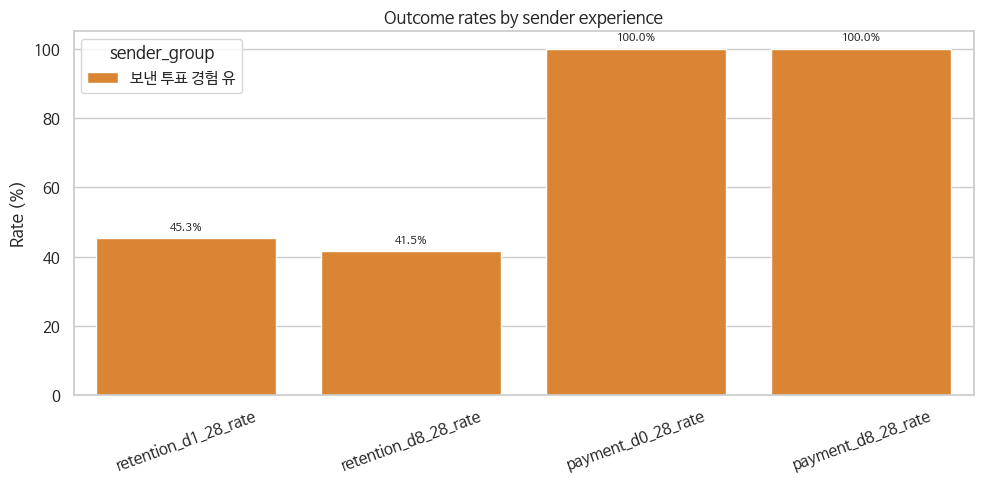

saved figure: /content/sender_behavior_axis_outputs/figures/04_eda_active_days_mean_by_sender_group.png


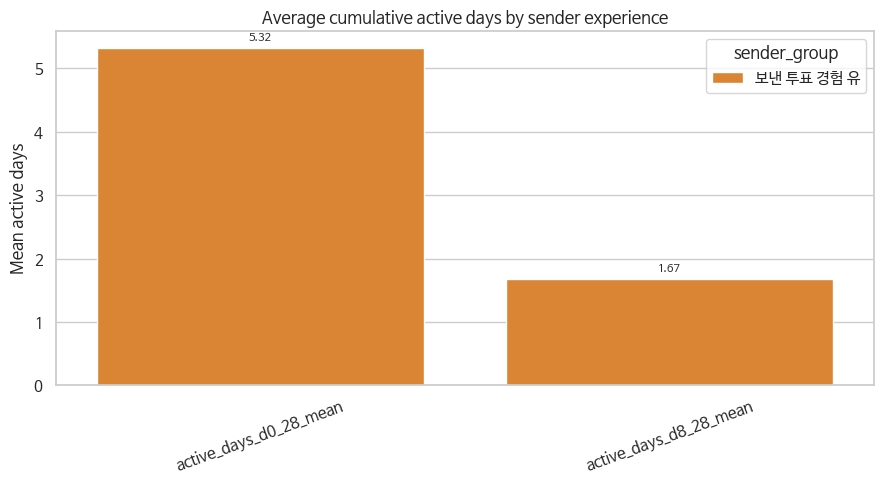

saved figure: /content/sender_behavior_axis_outputs/figures/05_eda_active_days_boxplot.png


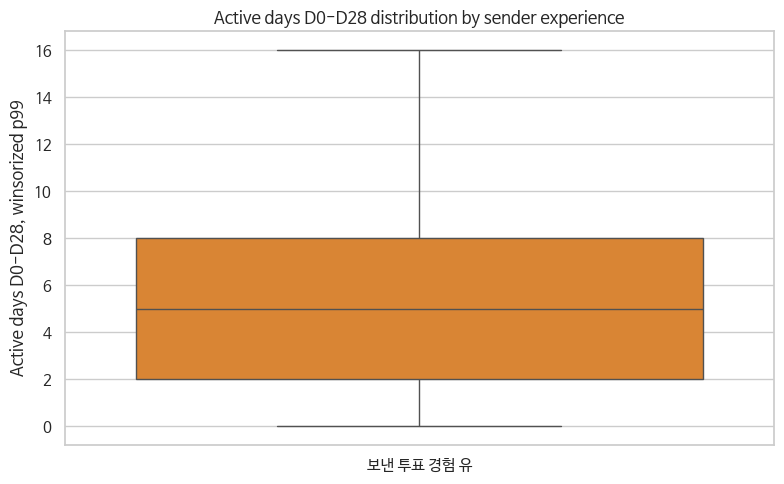

saved figure: /content/sender_behavior_axis_outputs/figures/06_eda_sent_vote_window_rate.png


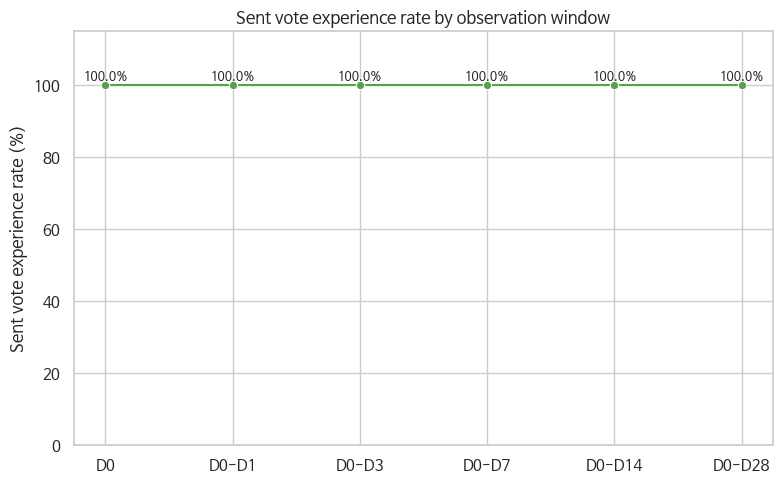

saved table: /content/sender_behavior_axis_outputs/tables/08_sent_vote_window_rate.csv


#### Sent vote experience rate by observation window

,window,sent_vote_rate
0,D0,100.0
1,D0-D1,100.0
2,D0-D3,100.0
3,D0-D7,100.0
4,D0-D14,100.0
5,D0-D28,100.0


saved figure: /content/sender_behavior_axis_outputs/figures/07_eda_sent_vote_count_distribution.png


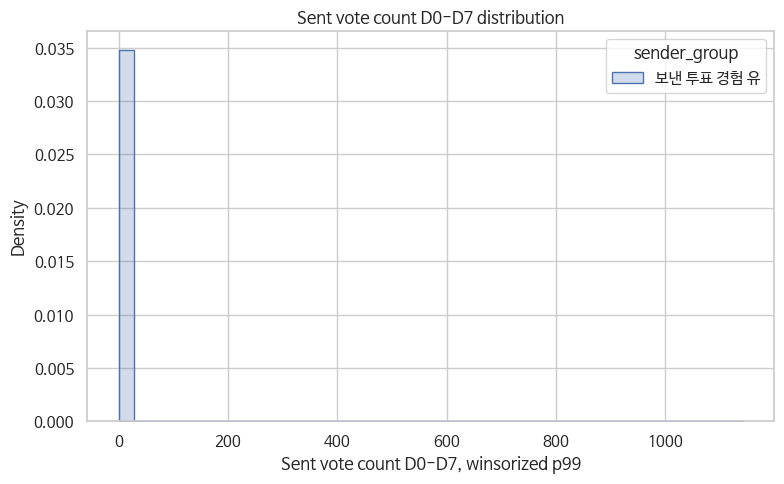

saved figure: /content/sender_behavior_axis_outputs/figures/08_eda_correlation_heatmap.png


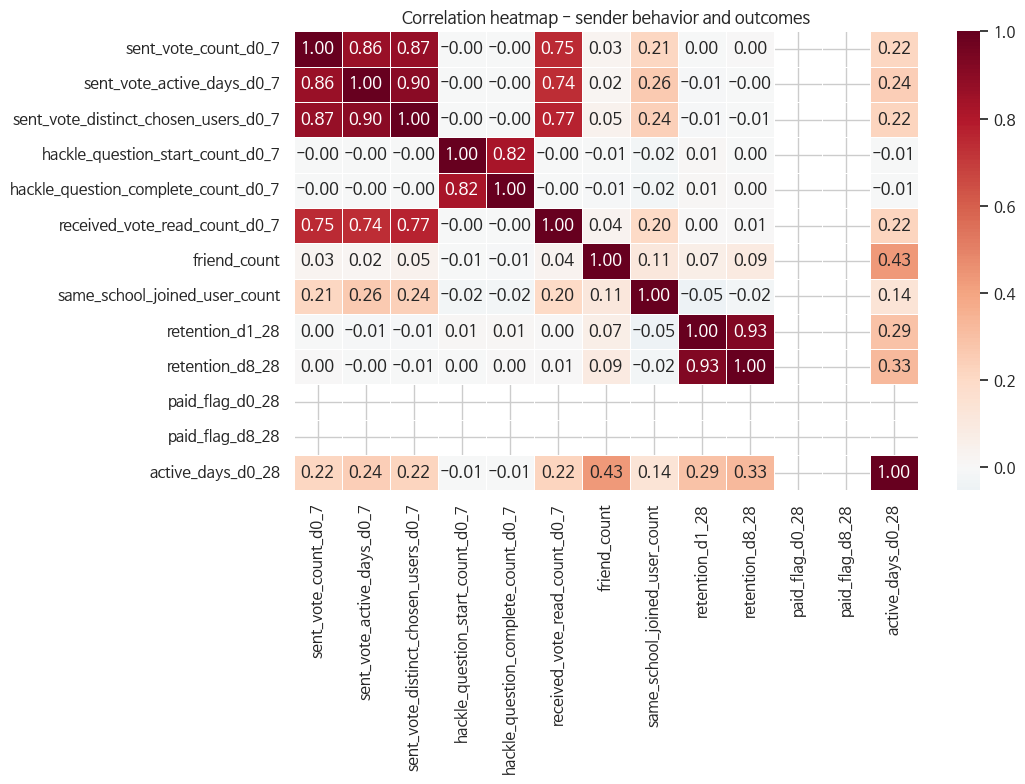

PosixPath('/content/sender_behavior_axis_outputs/figures/08_eda_correlation_heatmap.png')

In [18]:
home_df = analysis_df.loc[analysis_df["home_entry_population"]].copy()
home_df["sent_vote_count_d0_7_w"] = winsorize_series(home_df["sent_vote_count_d0_7"], 0.99)
home_df["active_days_d0_28_w"] = winsorize_series(home_df["active_days_d0_28"], 0.99)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=population_funnel, x="population", y="user_count", ax=ax, color="#4C78A8")
ax.set_title("Population funnel")
ax.set_xlabel("")
ax.set_ylabel("User count")
format_count_axis(ax)
add_bar_labels(ax, decimals=0)
save_fig("Population funnel", "eda_population_funnel", fig)

fig, ax = plt.subplots(figsize=(7, 5))
sender_counts = home_df.groupby("sender_group", as_index=False).agg(user_count=("user_id", "nunique"))
sns.barplot(data=sender_counts, x="sender_group", y="user_count", ax=ax, palette=["#F58518", "#4C78A8"])
ax.set_title("Sender group size - home-entry population")
ax.set_xlabel("")
ax.set_ylabel("User count")
format_count_axis(ax)
add_bar_labels(ax, decimals=0)
save_fig("Sender group size", "eda_sender_group_size", fig)

rate_plot = home_summary.melt(
    id_vars=["sender_group"],
    value_vars=["retention_d1_28_rate", "retention_d8_28_rate", "payment_d0_28_rate", "payment_d8_28_rate"],
    var_name="metric",
    value_name="rate_pct",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=rate_plot, x="metric", y="rate_pct", hue="sender_group", ax=ax, palette=["#F58518", "#4C78A8"])
ax.set_title("Outcome rates by sender experience")
ax.set_xlabel("")
ax.set_ylabel("Rate (%)")
ax.tick_params(axis="x", rotation=20)
add_bar_labels(ax, decimals=1, suffix="%")
save_fig("Outcome rates by sender experience", "eda_outcome_rates_by_sender_group", fig)

active_mean_plot = home_summary.melt(
    id_vars=["sender_group"],
    value_vars=["active_days_d0_28_mean", "active_days_d8_28_mean"],
    var_name="metric",
    value_name="mean_days",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=active_mean_plot, x="metric", y="mean_days", hue="sender_group", ax=ax, palette=["#F58518", "#4C78A8"])
ax.set_title("Average cumulative active days by sender experience")
ax.set_xlabel("")
ax.set_ylabel("Mean active days")
ax.tick_params(axis="x", rotation=20)
add_bar_labels(ax, decimals=2)
save_fig("Average cumulative active days by sender experience", "eda_active_days_mean_by_sender_group", fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=home_df, x="sender_group", y="active_days_d0_28_w", ax=ax, palette=["#F58518", "#4C78A8"])
ax.set_title("Active days D0-D28 distribution by sender experience")
ax.set_xlabel("")
ax.set_ylabel("Active days D0-D28, winsorized p99")
save_fig("Active days distribution by sender experience", "eda_active_days_boxplot", fig)

window_rate = pd.DataFrame(
    {
        "window": ["D0", "D0-D1", "D0-D3", "D0-D7", "D0-D14", "D0-D28"],
        "sent_vote_rate": [
            home_df["sent_vote_experience_d0"].mean() * 100,
            home_df["sent_vote_experience_d0_1"].mean() * 100,
            home_df["sent_vote_experience_d0_3"].mean() * 100,
            home_df["sent_vote_experience_d0_7"].mean() * 100,
            home_df["sent_vote_experience_d0_14"].mean() * 100,
            home_df["sent_vote_experience_d0_28"].mean() * 100,
        ],
    }
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=window_rate, x="window", y="sent_vote_rate", marker="o", ax=ax, color="#54A24B")
ax.set_title("Sent vote experience rate by observation window")
ax.set_xlabel("")
ax.set_ylabel("Sent vote experience rate (%)")
ax.set_ylim(0, max(5, window_rate["sent_vote_rate"].max() * 1.15))
for x, y in zip(window_rate["window"], window_rate["sent_vote_rate"]):
    ax.text(x, y, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
save_fig("Sent vote experience rate by observation window", "eda_sent_vote_window_rate", fig)
save_table(window_rate, "Sent vote experience rate by observation window", "sent_vote_window_rate")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=home_df, x="sent_vote_count_d0_7_w", hue="sender_group", bins=40, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Sent vote count D0-D7 distribution")
ax.set_xlabel("Sent vote count D0-D7, winsorized p99")
ax.set_ylabel("Density")
save_fig("Sent vote count D0-D7 distribution", "eda_sent_vote_count_distribution", fig)

corr_cols = [
    "sent_vote_count_d0_7",
    "sent_vote_active_days_d0_7",
    "sent_vote_distinct_chosen_users_d0_7",
    "hackle_question_start_count_d0_7",
    "hackle_question_complete_count_d0_7",
    "received_vote_read_count_d0_7",
    "friend_count",
    "same_school_joined_user_count",
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
    "active_days_d0_28",
]
corr_cols = [c for c in corr_cols if c in home_df.columns]
corr_df = home_df[corr_cols].copy()
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce").fillna(0)
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_df.corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("Correlation heatmap - sender behavior and outcomes")
save_fig("Correlation heatmap", "eda_correlation_heatmap", fig)

# ## 14. Sender Behavior Segment Clustering